# Exploratory Data Analysis

Conduct a high level statistical analysis on the continous and categorical variables.

In [39]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Load the data into a pandas DataFrame
df = pd.read_csv('outputs/train_cleaned.csv')

# Display the shape of the data
print(df.shape)

(1460, 81)


In [41]:
# # Ensure there are no missing values in the data
# missing_values = df.isnull().sum()
# missing_values = missing_values[missing_values > 0]

# # Get the data types of the features with missing values
# missing_values_data_types = df.dtypes[missing_values.index]

# # Combine the missing values and data types into a single DataFrame
# missing_values_info = pd.DataFrame({'Missing Values': missing_values, 'Data Type': missing_values_data_types})

# print(missing_values_info)

In [42]:
# # List of columns to fill missing values
# columns = ['GarageQualScore', 'GarageCondScore']

# # Loop through each column and fill missing values with the median
# for column in columns:
#     df[column] = df[column].fillna(df[column].median())

In [43]:
# # Remove the outliers from the data using the IQR method
# # Calculate Q1 (25th percentile) and Q3 (75th percentile)
# Q1 = df['SalePrice'].quantile(0.25)
# Q3 = df['SalePrice'].quantile(0.75)

# # Compute the Interquartile Range (IQR)
# IQR = Q3 - Q1

# # Define the lower and upper bounds
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # Filter out the outliers
# df = df[(df['SalePrice'] >= lower_bound) & (df['SalePrice'] <= upper_bound)]

## Review the SalesPrice Label

In [44]:
# View the statistical data for the SalePrice column
mean_price = df['SalePrice'].mean().round(2)
median_price = df['SalePrice'].median()
mode_price = df['SalePrice'].mode()[0]
std_price = df['SalePrice'].std().round(3)
min_price = df['SalePrice'].min()
max_price = df['SalePrice'].max()
distribution_price = df['SalePrice'].skew()

# Print the data
print(f'Mean: {mean_price}')
print(f'Median: {median_price}')
print(f'Mode: {mode_price}')
print(f'Standard Deviation: {std_price}')
print(f'Minimum: {min_price}')
print(f'Maximum: {max_price}')
print(f'Distribution: {distribution_price}')


Mean: 180921.2
Median: 163000.0
Mode: 140000
Standard Deviation: 79442.503
Minimum: 34900
Maximum: 755000
Distribution: 1.8828757597682129


Text(0.5, 1.0, 'Distribution of Sale Price')

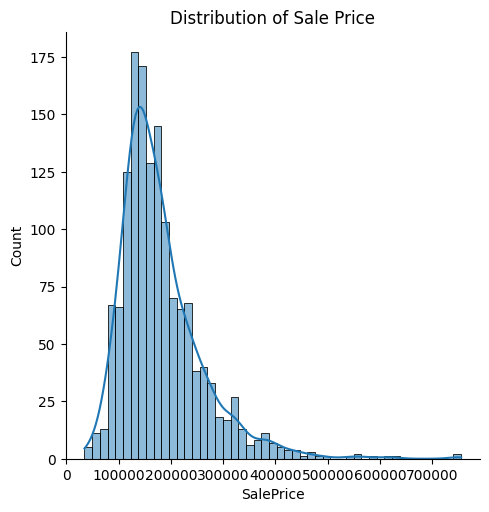

In [45]:
# View the distribution of the data
sns.displot(df['SalePrice'], kde=True)
plt.title('Distribution of Sale Price')

In [46]:
# Square root transformation to the SalePrice column to reduce skewness
df['SalePrice'] = np.sqrt(df['SalePrice'])

In [47]:
# View the statistical data for the SalePrice column
mean_price = df['SalePrice'].mean().round(2)
median_price = df['SalePrice'].median()
mode_price = df['SalePrice'].mode()[0]
std_price = df['SalePrice'].std().round(3)
min_price = df['SalePrice'].min()
max_price = df['SalePrice'].max()
distribution_price = df['SalePrice'].skew()

# Print the data
print(f'Mean: {mean_price}')
print(f'Median: {median_price}')
print(f'Mode: {mode_price}')
print(f'Standard Deviation: {std_price}')
print(f'Minimum: {min_price}')
print(f'Maximum: {max_price}')
print(f'Distribution: {distribution_price}')

Mean: 416.62
Median: 403.732584763727
Mode: 374.16573867739413
Standard Deviation: 85.769
Minimum: 186.81541692269406
Maximum: 868.9073598491384
Distribution: 0.9431527373310963


Text(0.5, 1.0, 'Distribution of Sale Price')

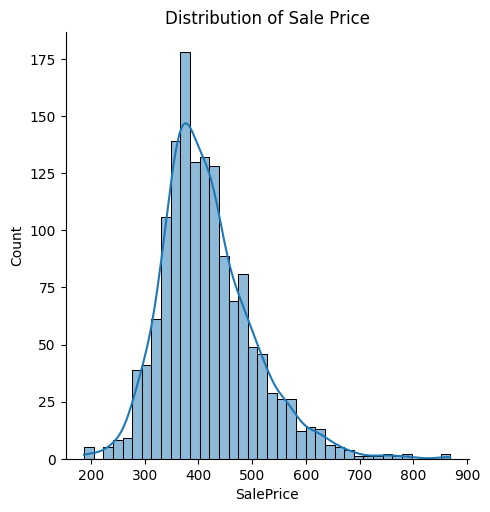

In [48]:
# View the distribution of the data
sns.displot(df['SalePrice'], kde=True)
plt.title('Distribution of Sale Price')

## View the statistical data of the continuous data

In [49]:
# Remove the integer columns that are not continuous
statistical_data = df.drop(['Id'], axis=1)  # No inplace=True

# Create a data frame of the statistical data
statistical_data = statistical_data.describe().round(2)

# Export the data to review the output
statistical_data.to_csv('outputs/statistical_data.csv', index=False)


In [50]:
# # There is a -1 values in the RemodAge column, which is not possible
# # Replace all values less than 0 with 0
# df['RemodAge'] = df['RemodAge'].apply(lambda x: 0 if x < 0 else x)

In [51]:
# # Check if there are still -1 values in the RemodAge column
# remodage_values = df['RemodAge'].value_counts()
# print(remodage_values)

In [52]:
# Create a dataframe for the continuous variables
continuous_data = df.select_dtypes(include='number')

# drop the Id column
continuous_data.drop('Id', axis=1, inplace=True)

# Display the first 5 rows of the continuous data
continuous_data.head()

# Export the continuous data to a csv file
continuous_data.to_csv('outputs/continuous_data.csv', index=False)


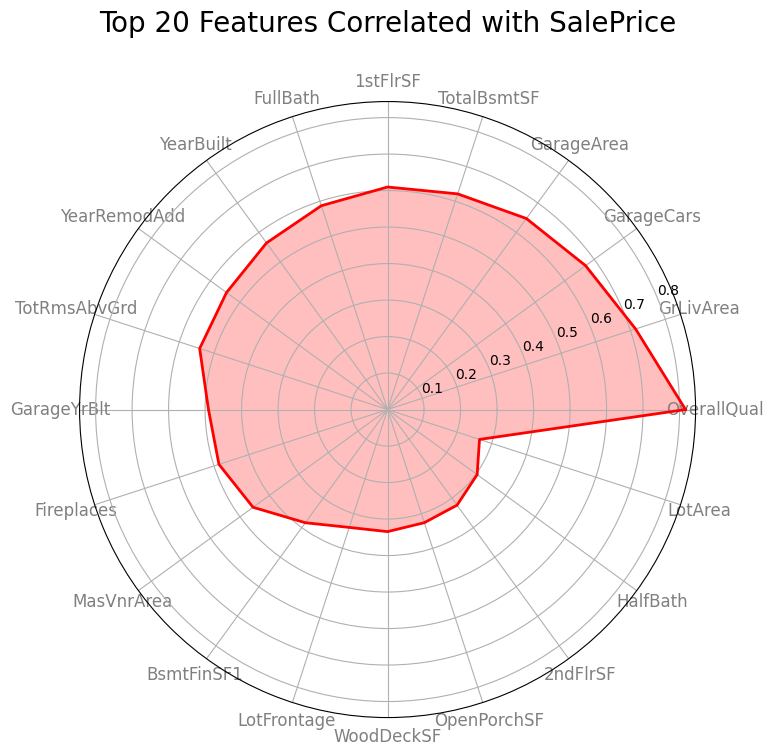

In [53]:
# Compute correlation
correlation_matrix = continuous_data.corr()

# Get correlation of all features with SalesPrice
correlation_with_salesprice = correlation_matrix['SalePrice'].drop('SalePrice')

# Sort correlations in descending order
correlation_ranked = correlation_with_salesprice.abs().sort_values(ascending=False)

# Select the top 20 features
top_20_features = correlation_ranked.head(20)

# Create a radar chart
categories = top_20_features.index
values = top_20_features.values

# Ensure the radar chart is circular
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values = np.concatenate((values, [values[0]]))
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], categories, color='grey', size=12)
ax.fill(angles, values, color='red', alpha=0.25)
ax.plot(angles, values, color='red', linewidth=2)

plt.title('Top 20 Features Correlated with SalePrice', size=20, color='black', y=1.1)
plt.show()


In [54]:
print(correlation_ranked)

OverallQual      0.816352
GrLivArea        0.714556
GarageCars       0.670686
GarageArea       0.647040
TotalBsmtSF      0.621384
1stFlrSF         0.609770
FullBath         0.587268
YearBuilt        0.564284
YearRemodAdd     0.545452
TotRmsAbvGrd     0.541377
GarageYrBlt      0.490732
Fireplaces       0.485827
MasVnrArea       0.455570
BsmtFinSF1       0.383322
LotFrontage      0.339562
WoodDeckSF       0.334462
OpenPorchSF      0.325927
2ndFlrSF         0.323811
HalfBath         0.303374
LotArea          0.264889
BsmtFullBath     0.235295
BsmtUnfSF        0.222704
BedroomAbvGr     0.189528
KitchenAbvGr     0.145002
EnclosedPorch    0.140801
ScreenPorch      0.117664
MSSubClass       0.081238
PoolArea         0.079852
OverallCond      0.061874
MoSold           0.054010
3SsnPorch        0.050693
YrSold           0.033047
LowQualFinSF     0.032851
MiscVal          0.020662
BsmtHalfBath     0.013069
BsmtFinSF2       0.003927
Name: SalePrice, dtype: float64


In [55]:
# import pandas as pd
# import numpy as np
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from sklearn.preprocessing import StandardScaler

# # Assuming df is your dataset, and target_col is the column you're predicting
# target_col = 'SalePrice'  # Replace with actual target column name
# features = continuous_data.drop(columns=[target_col])  # Drop target column

# # Drop non-numeric columns (if any)
# features = features.select_dtypes(include=[np.number])

# # Standardizing the features (not mandatory but helps with scaling)
# scaler = StandardScaler()
# features_scaled = scaler.fit_transform(features)

# # Compute VIF for each feature
# vif_data = pd.DataFrame()
# vif_data["Feature"] = features.columns
# vif_data["VIF"] = [variance_inflation_factor(features_scaled, i) for i in range(features_scaled.shape[1])]

# # Print results
# print("\nVariance Inflation Factor (VIF) Analysis:")
# print(vif_data.sort_values(by="VIF", ascending=False))

## Review the correlation between the sales price and all other continuous variables in a visual format

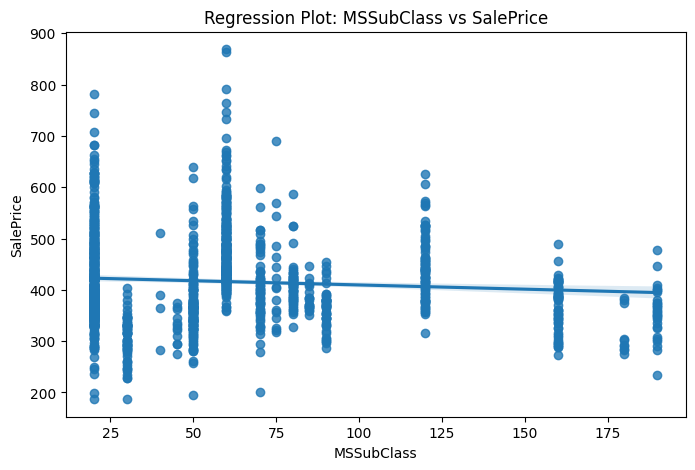

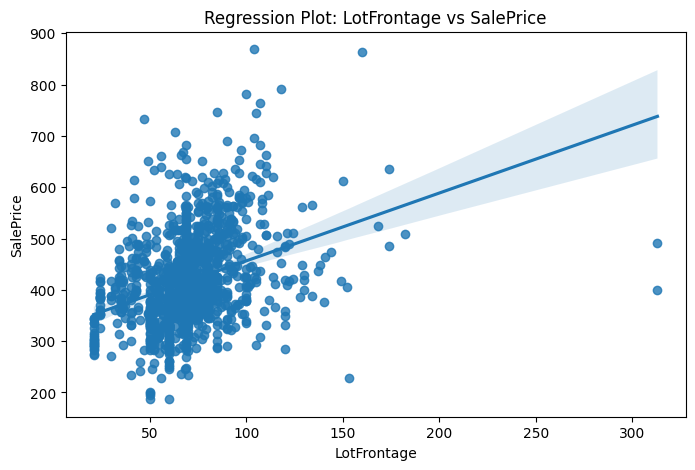

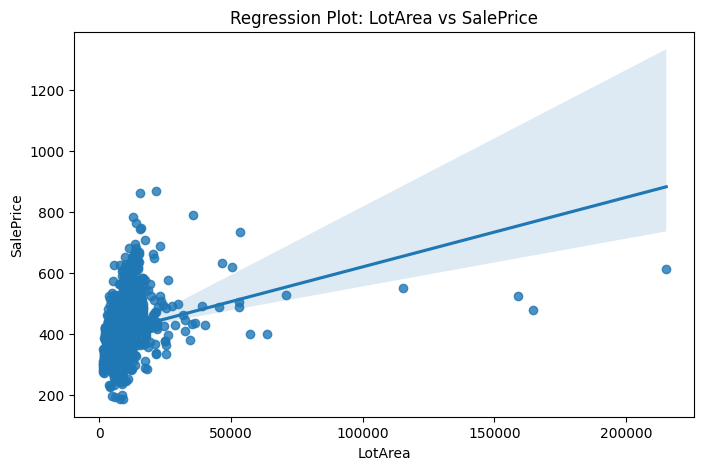

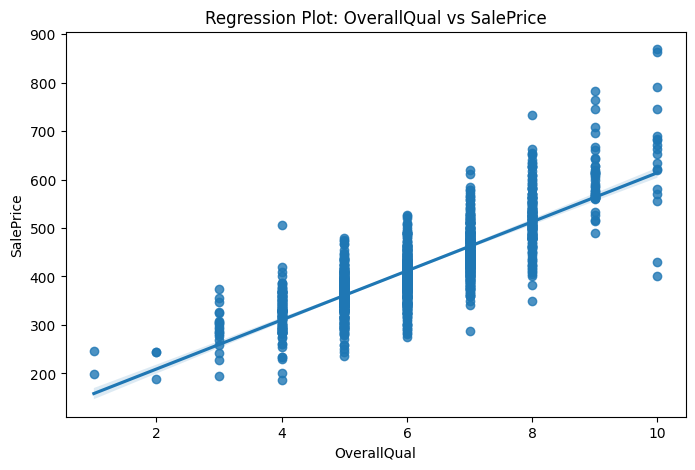

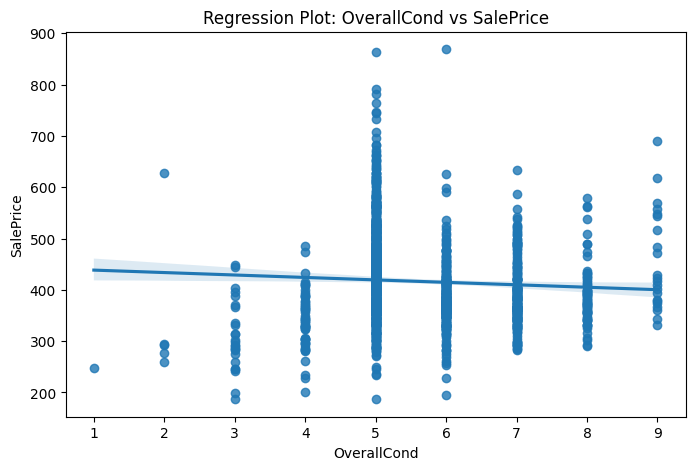

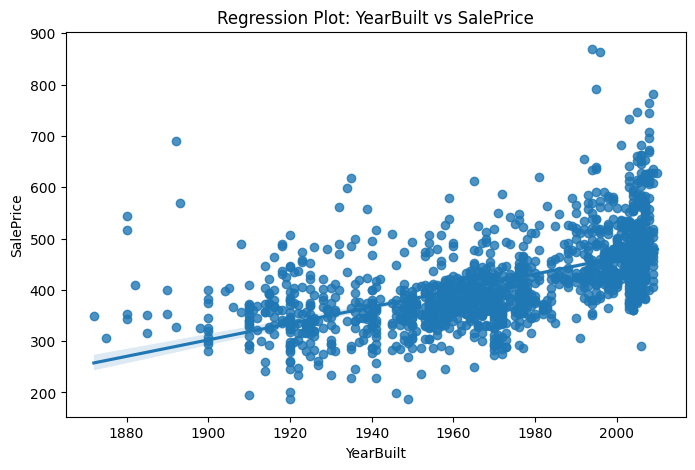

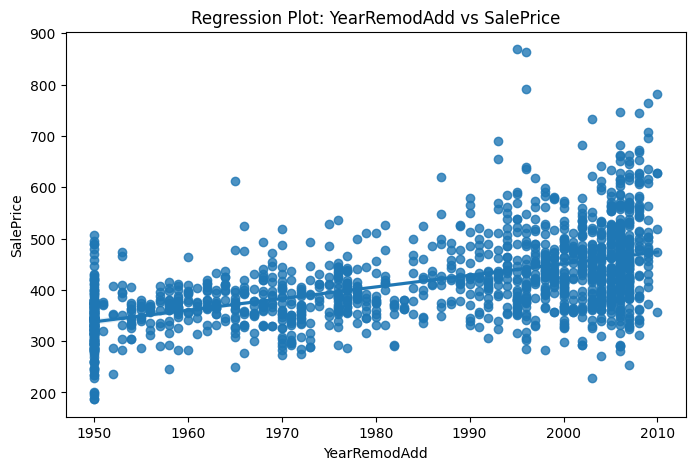

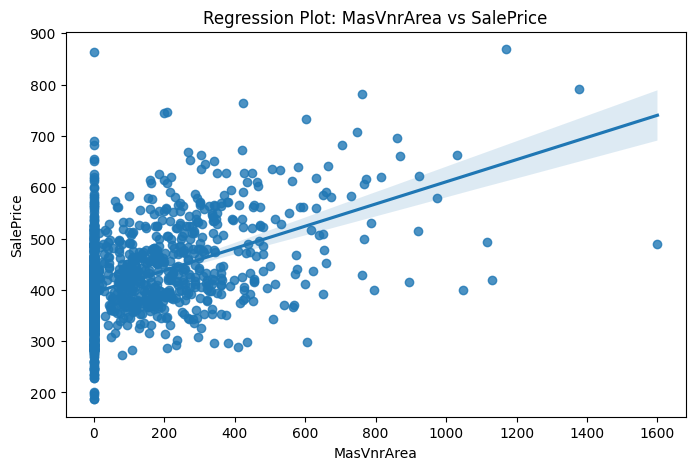

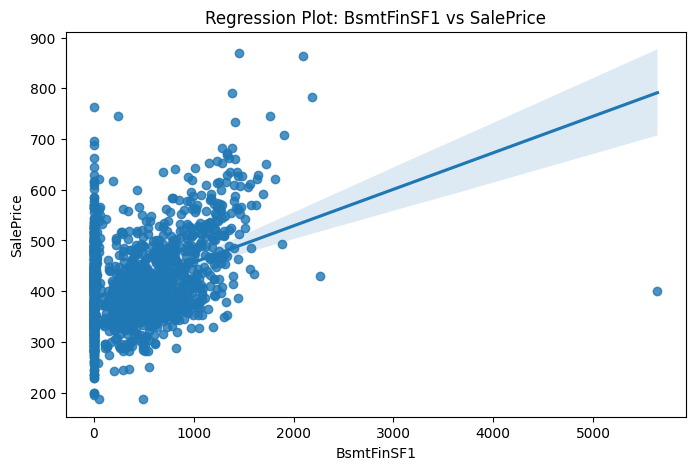

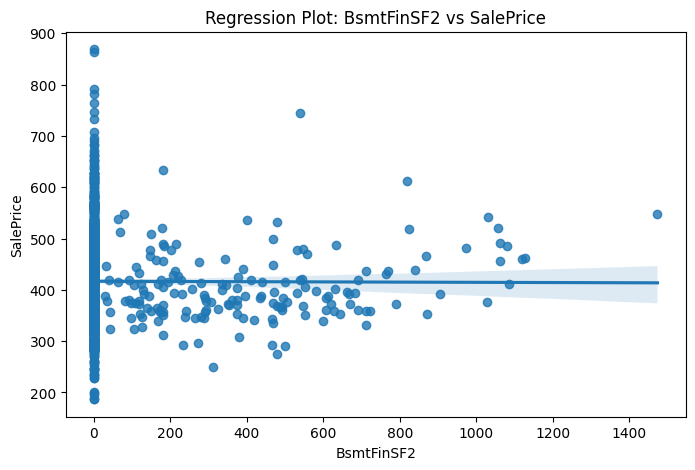

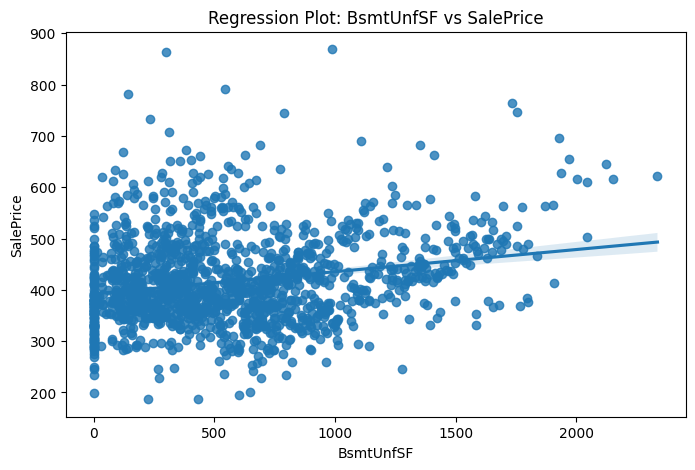

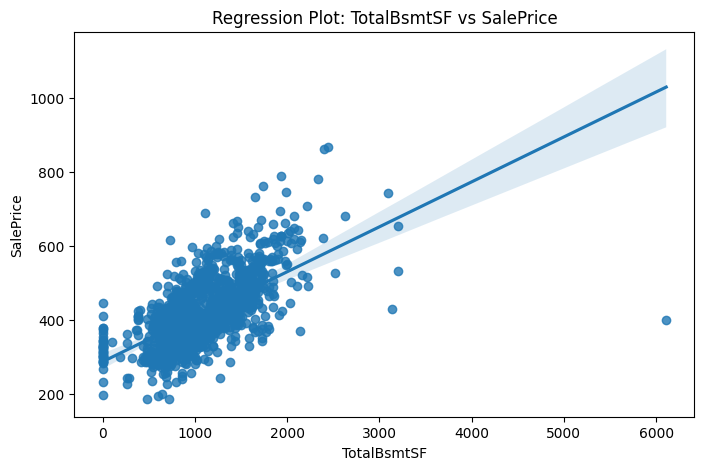

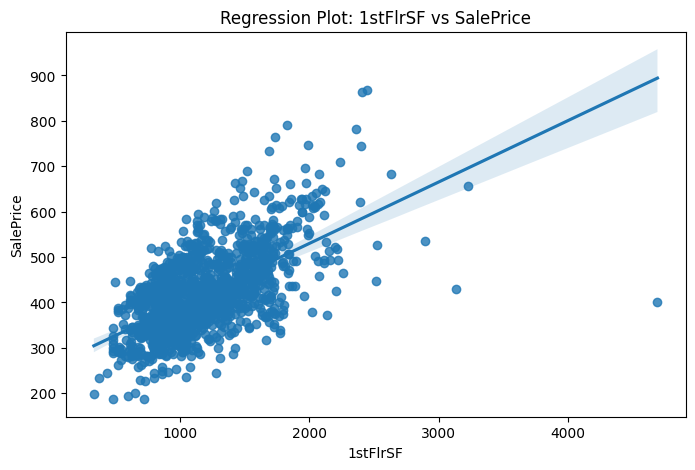

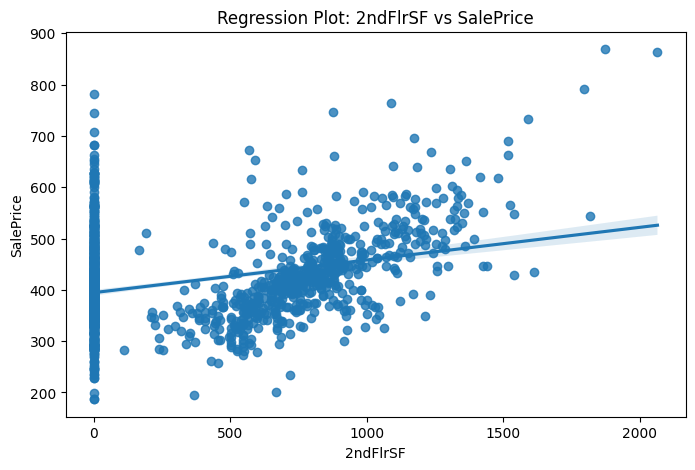

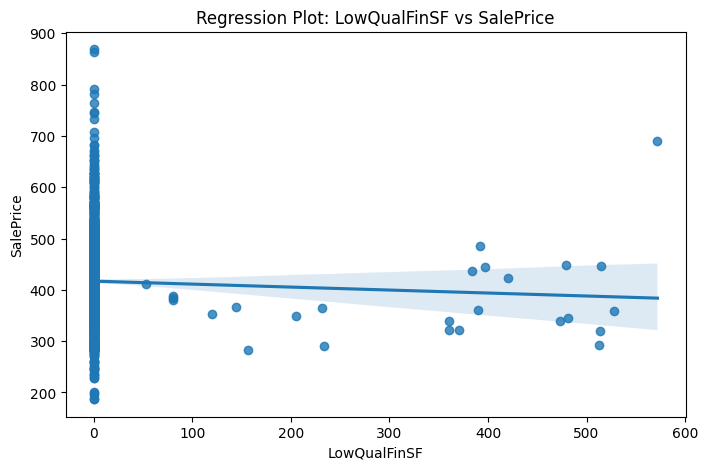

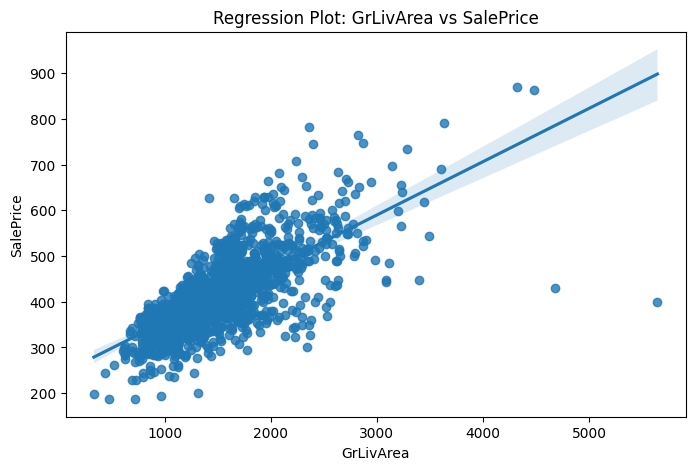

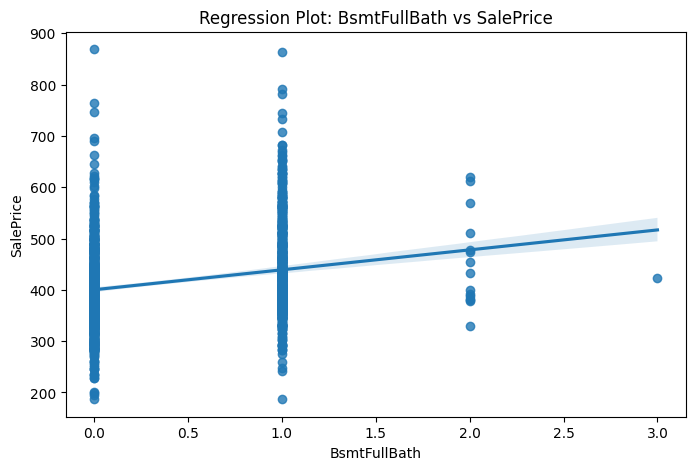

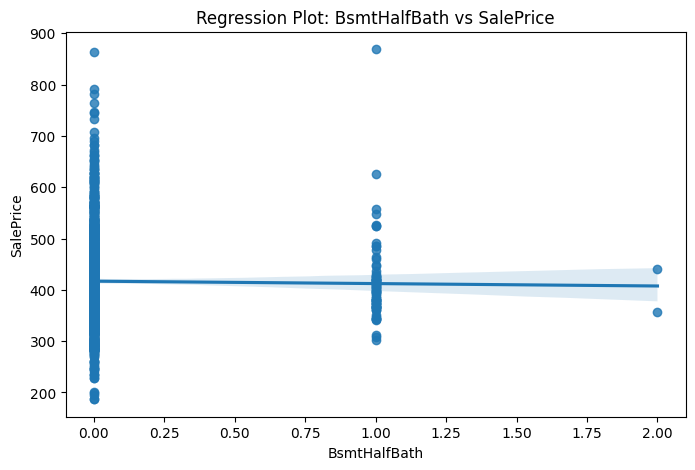

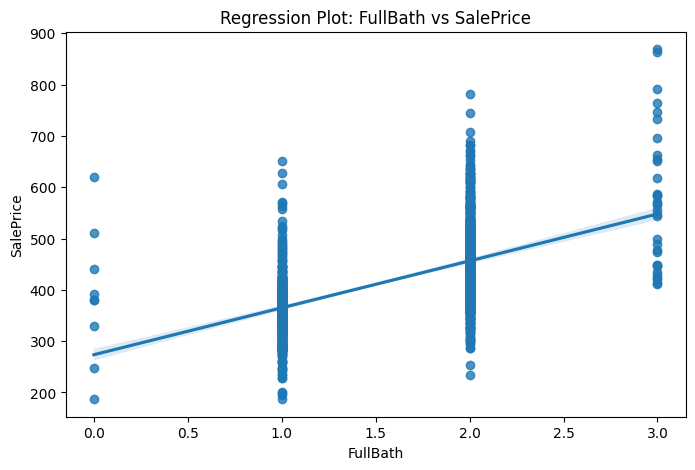

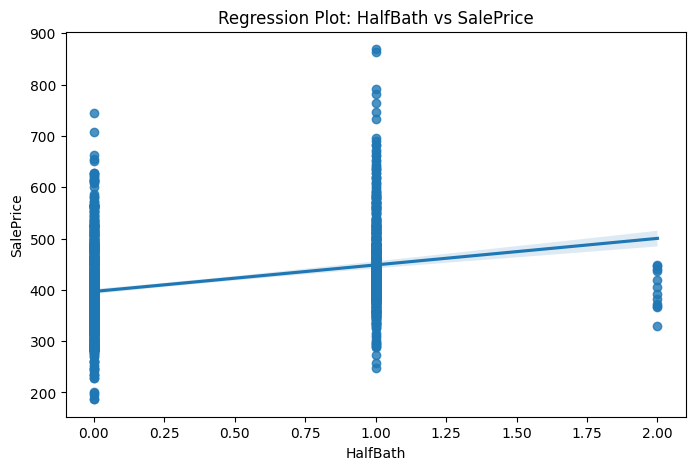

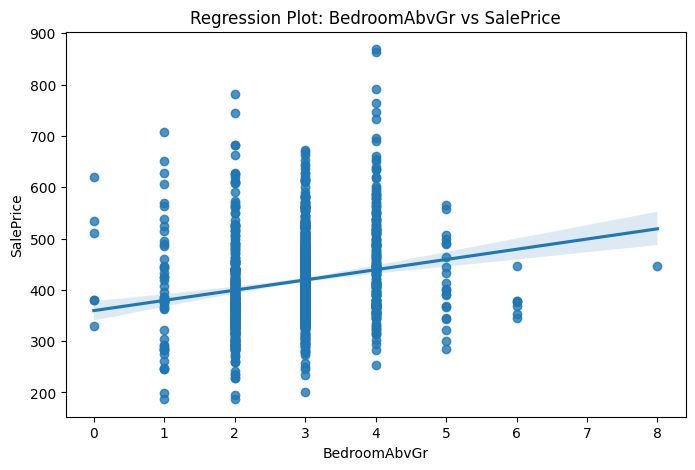

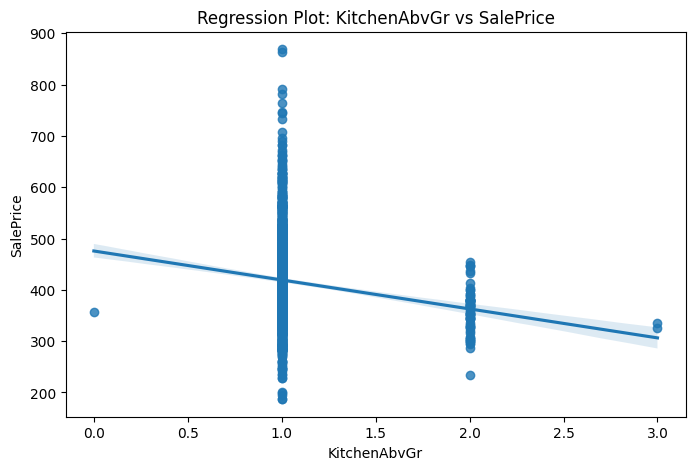

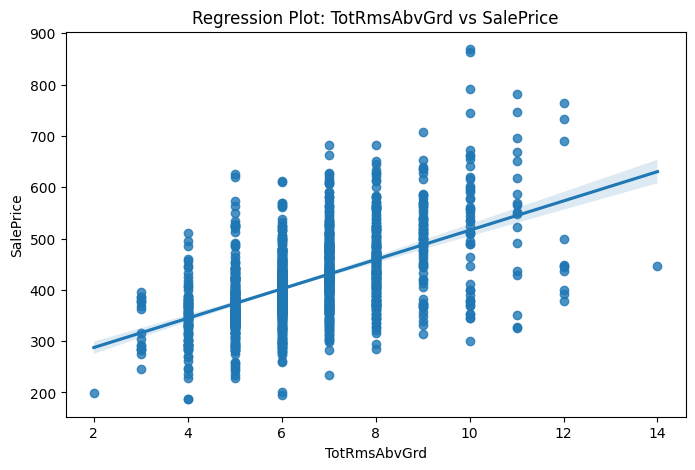

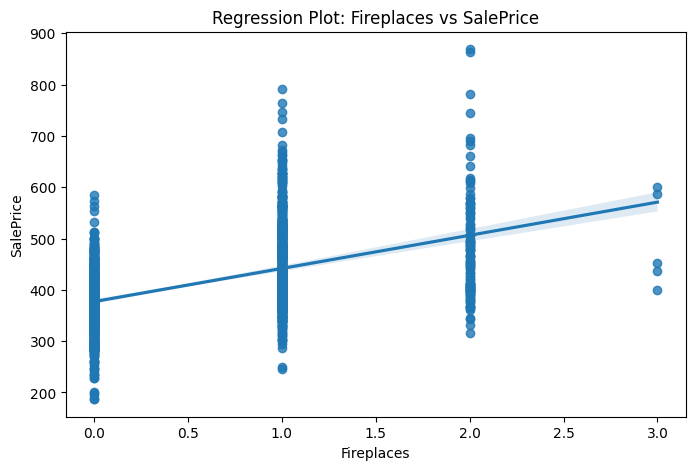

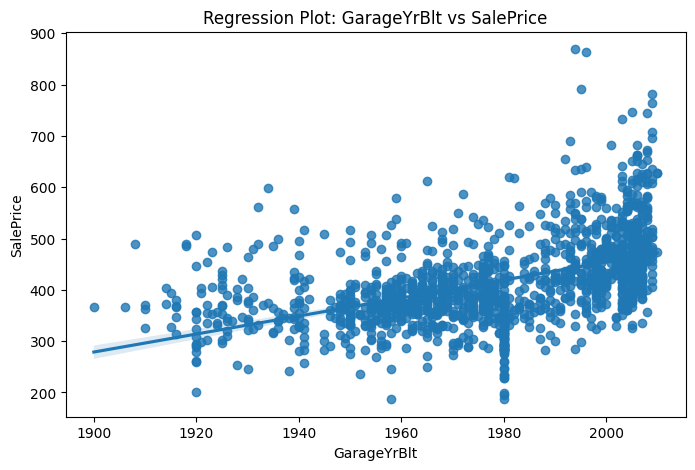

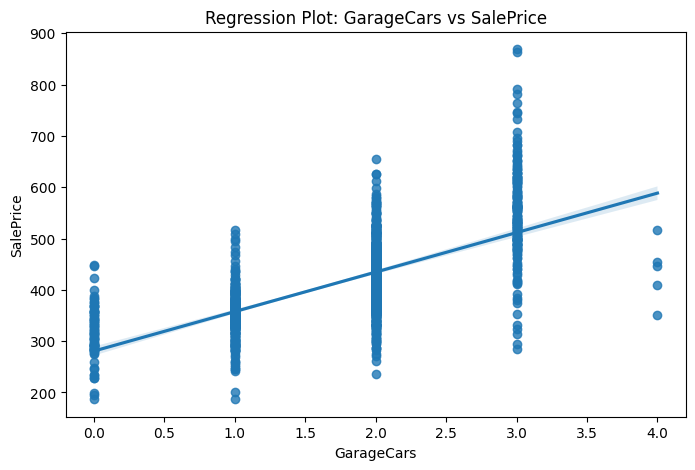

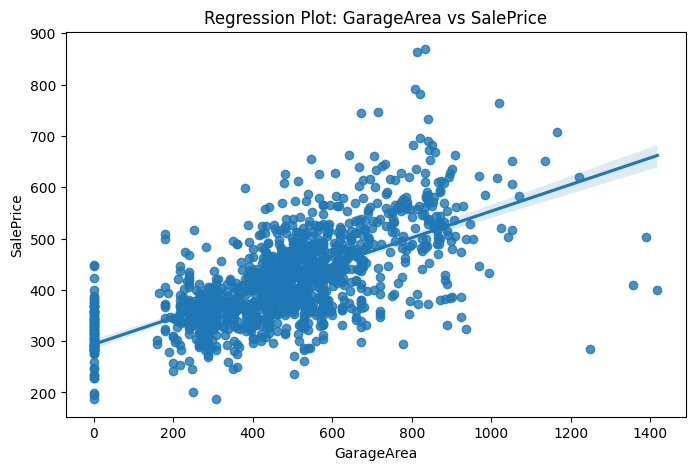

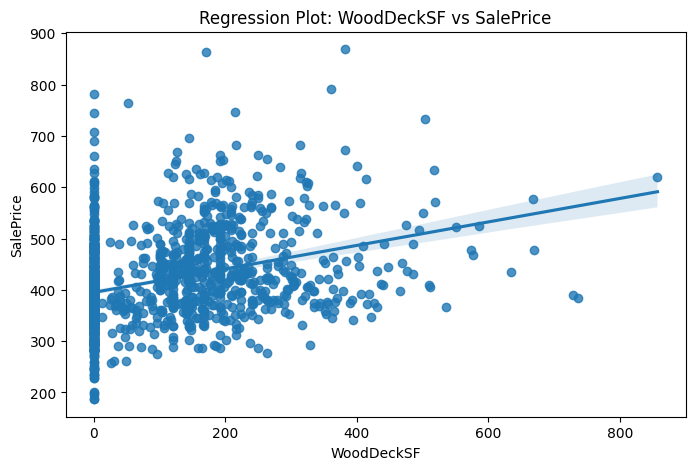

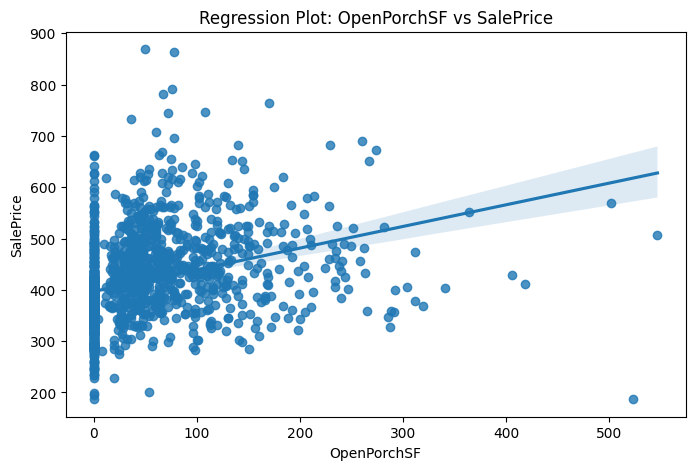

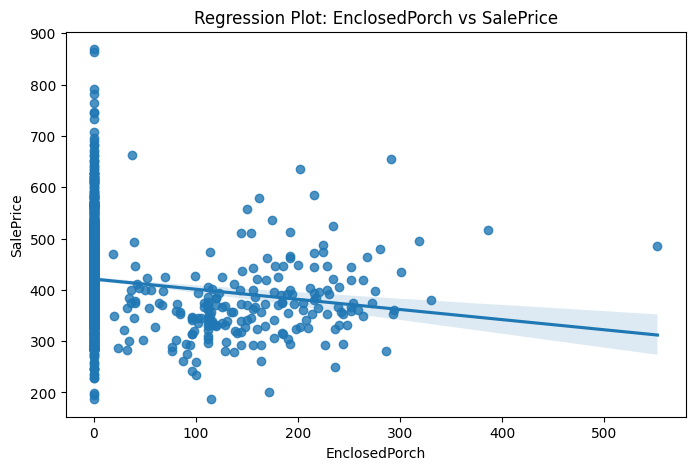

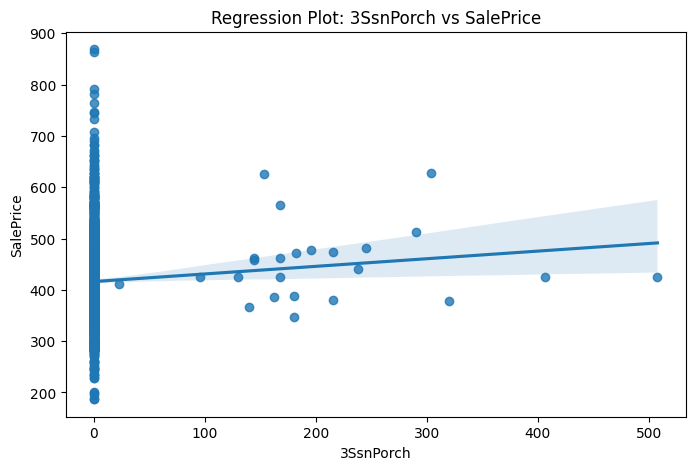

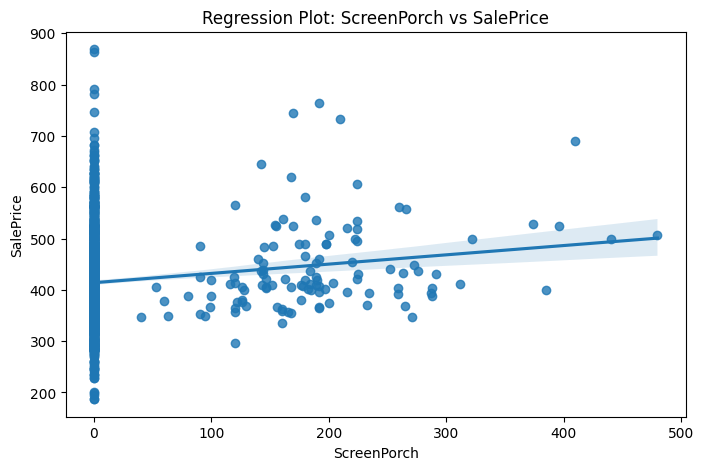

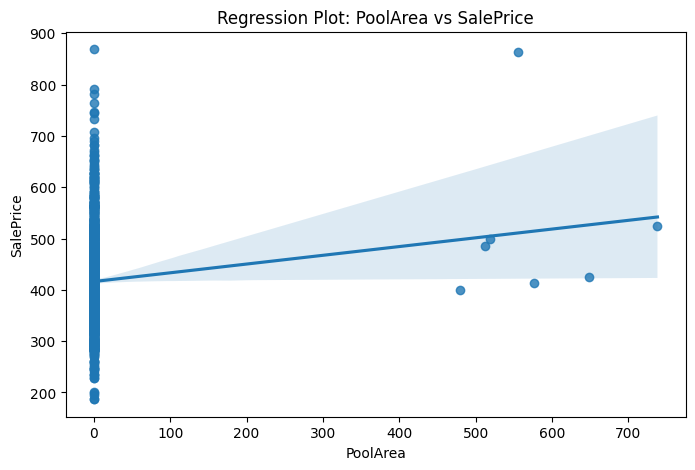

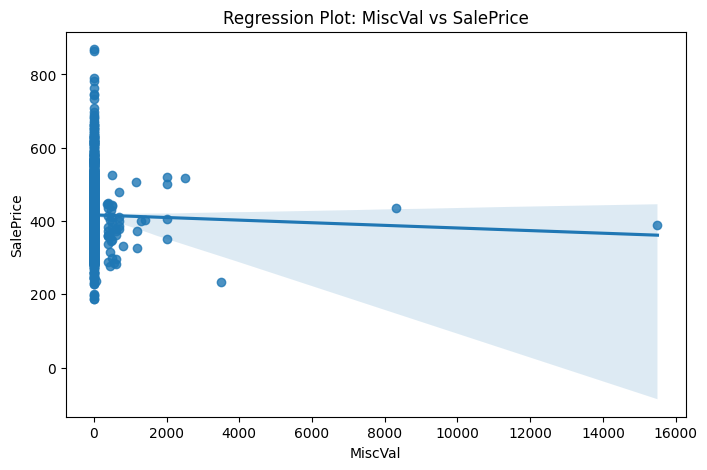

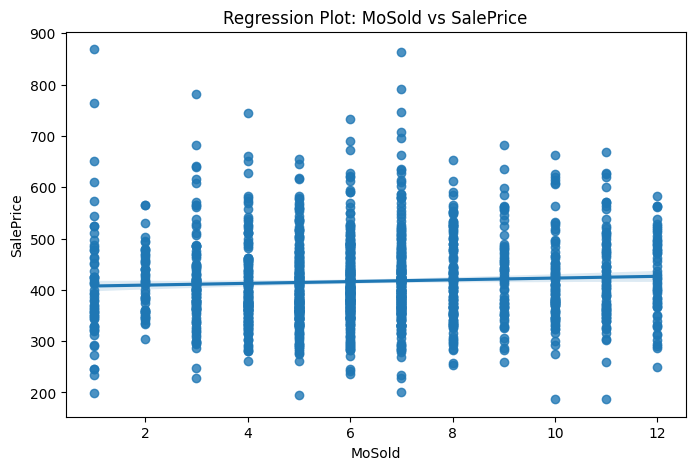

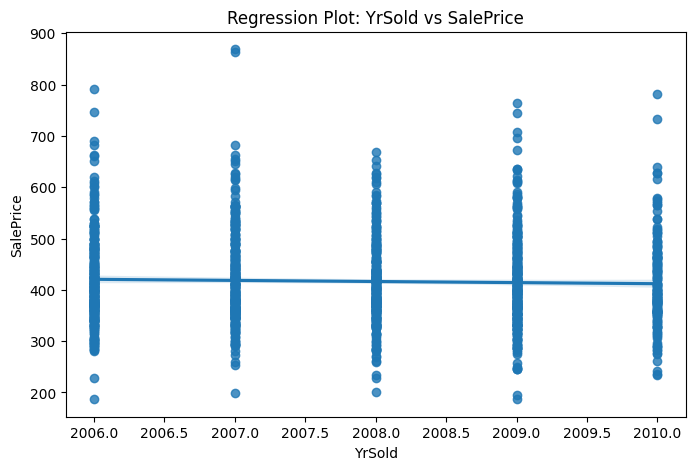

In [56]:
# Create regression plots for all numeric columns except 'SalePrice'
for col in continuous_data.columns:
    if col != 'SalePrice':  # Avoid plotting SalePrice against itself
        plt.figure(figsize=(8, 5))
        sns.regplot(x=continuous_data[col], y=continuous_data['SalePrice'])
        plt.xlabel(col)
        plt.ylabel('SalePrice')
        plt.title(f'Regression Plot: {col} vs SalePrice')
        plt.show()

## Categorical data

In [57]:
# Select object (categorical) columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# Add 'SalesPrice' to the selected columns
categorical_columns.append('SalePrice')

# Create categorical_data DataFrame
categorical_data = df[categorical_columns]

# Display the first 5 rows of the categorical data
categorical_data.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition,SalePrice
0,RL,Pave,Not Applicable,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,456.618002
1,RL,Pave,Not Applicable,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,426.028168
2,RL,Pave,Not Applicable,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,472.757866
3,RL,Pave,Not Applicable,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Unf,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Abnorml,374.165739
4,RL,Pave,Not Applicable,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,RFn,TA,TA,Y,Not Applicable,Not Applicable,Not Applicable,WD,Normal,500.000000


### Distribution

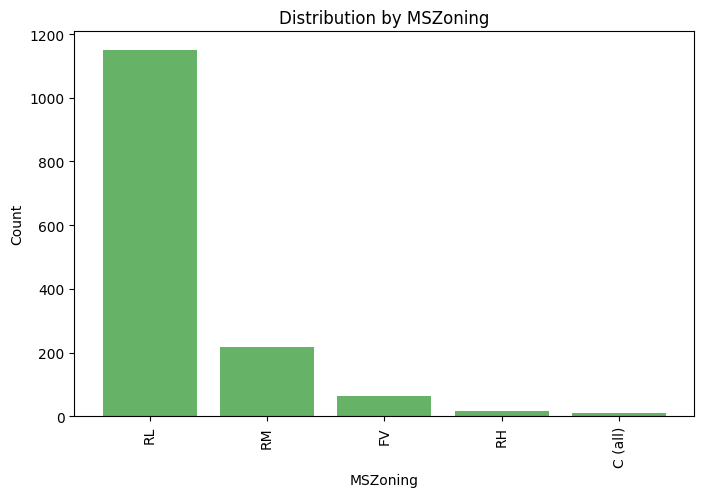

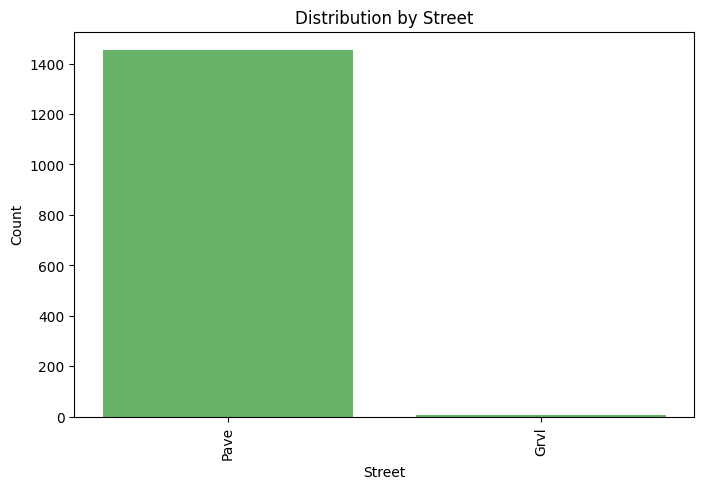

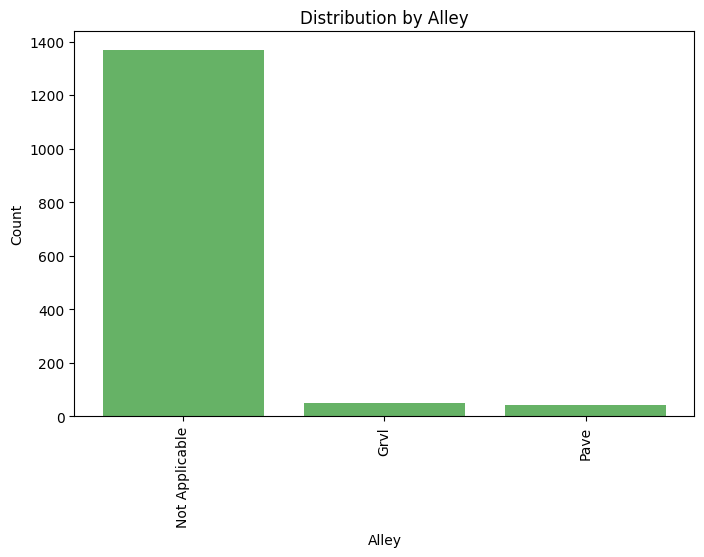

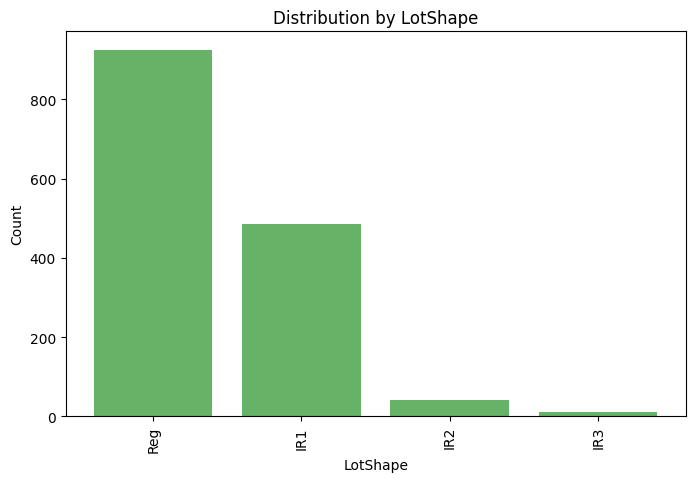

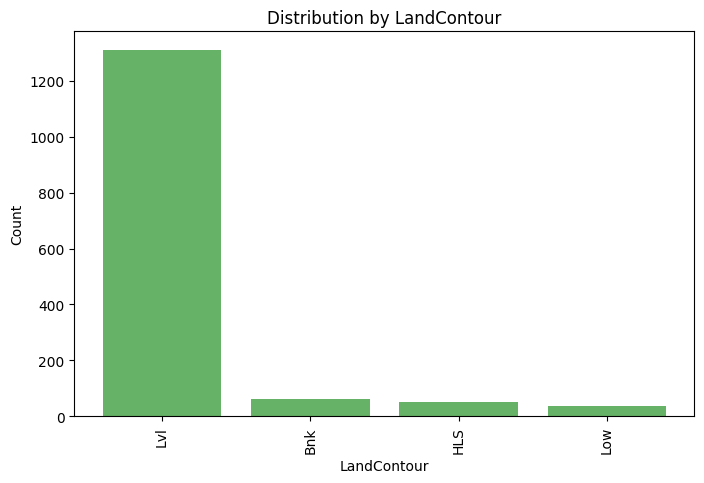

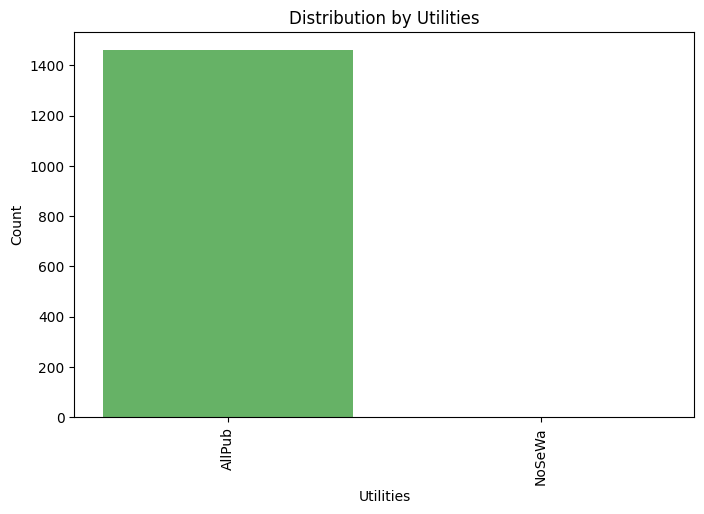

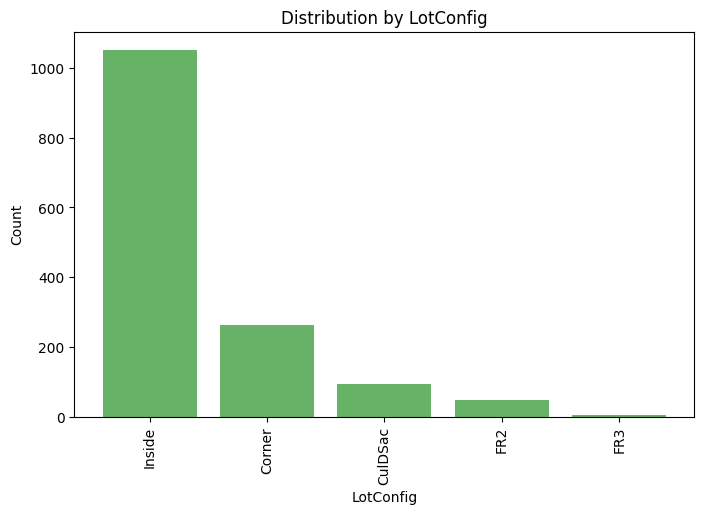

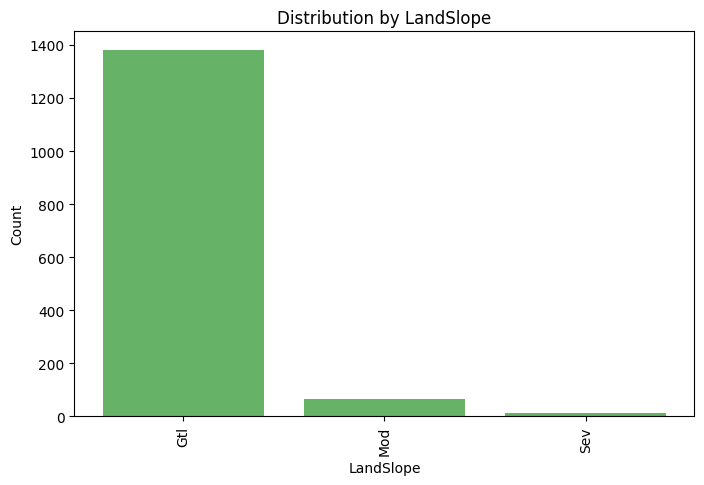

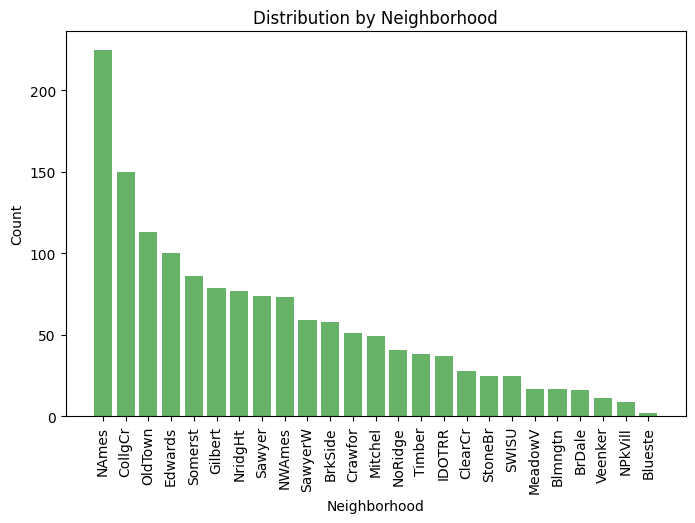

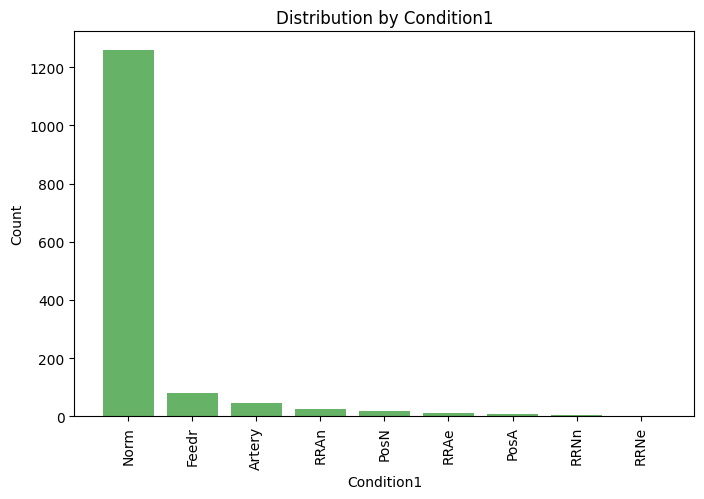

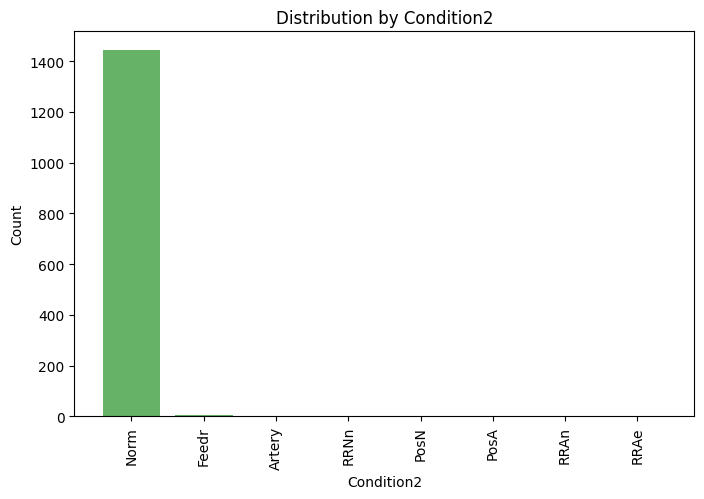

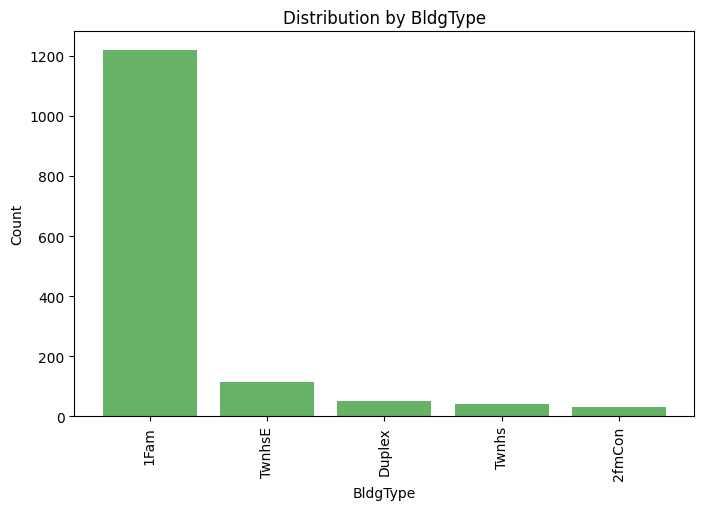

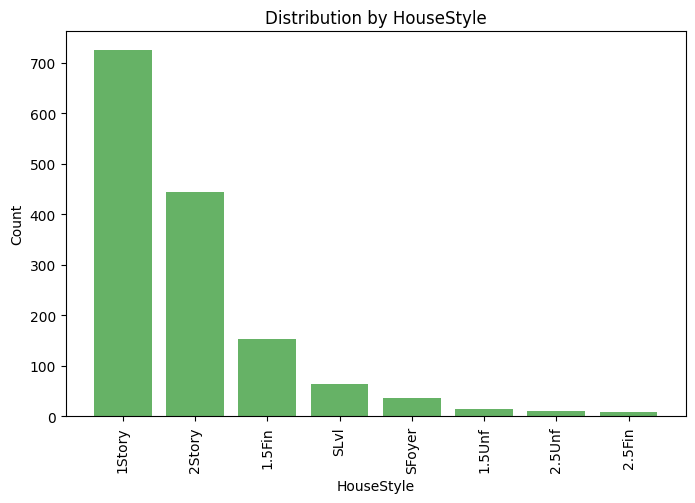

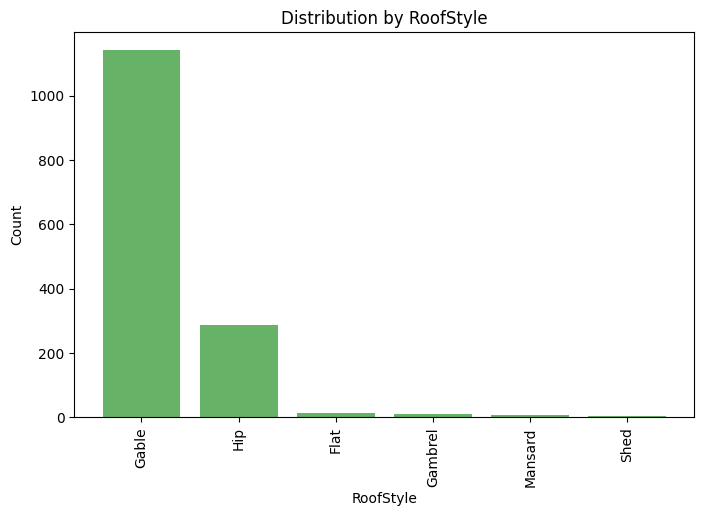

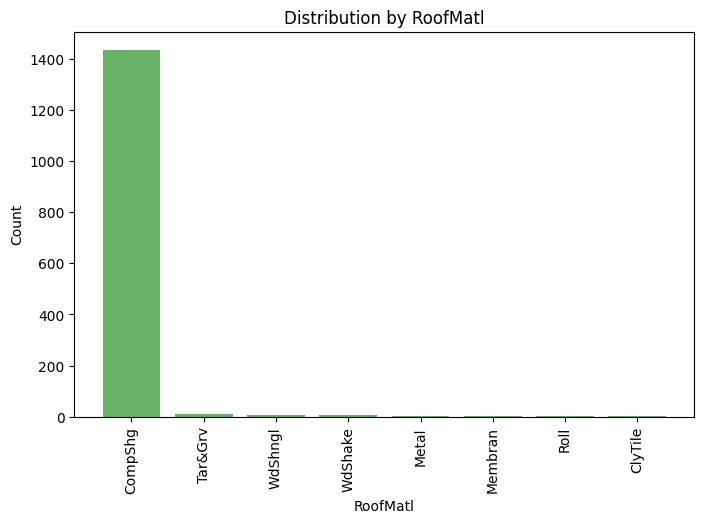

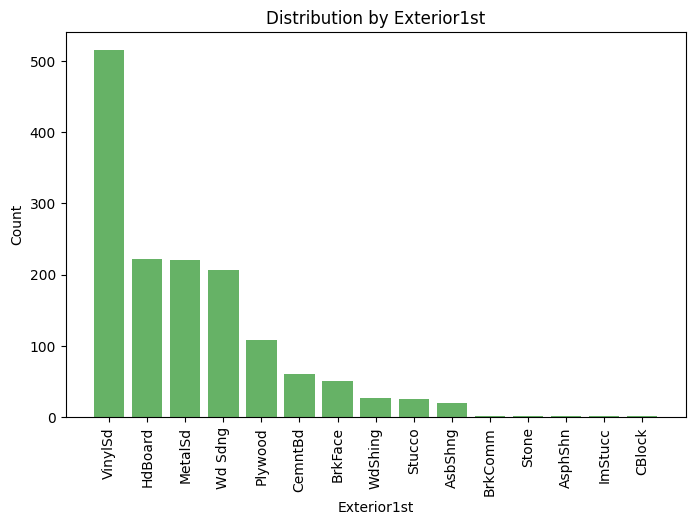

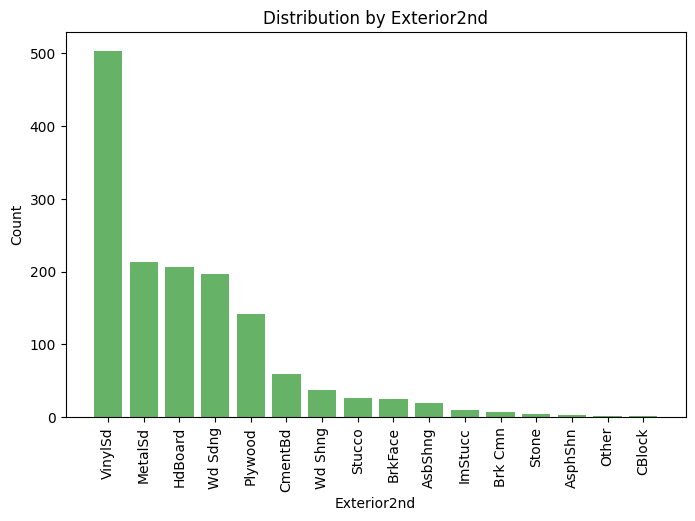

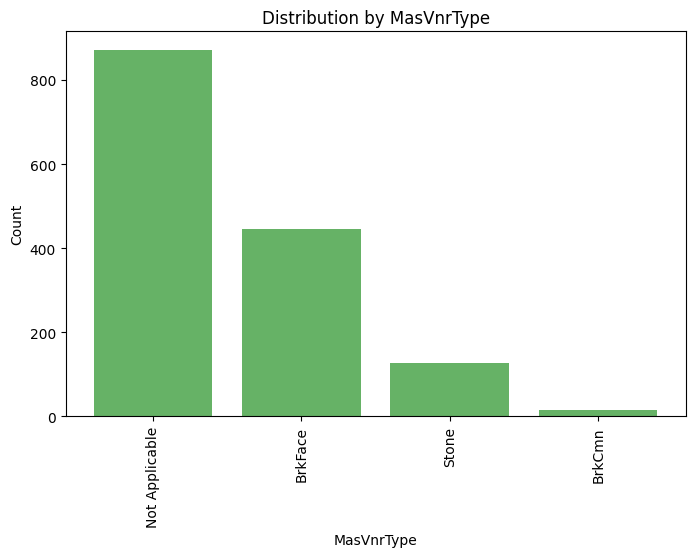

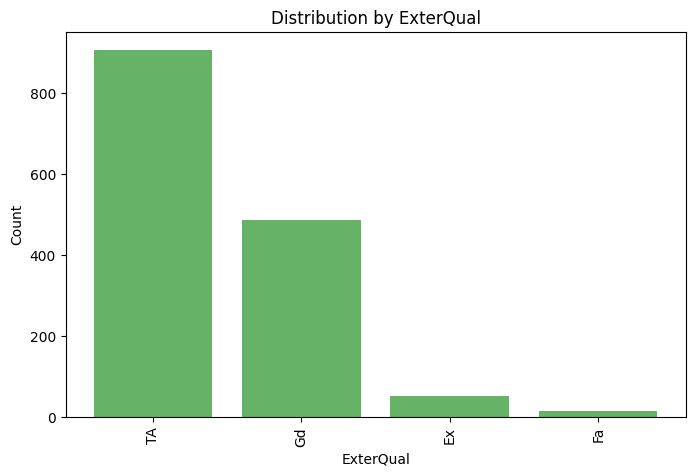

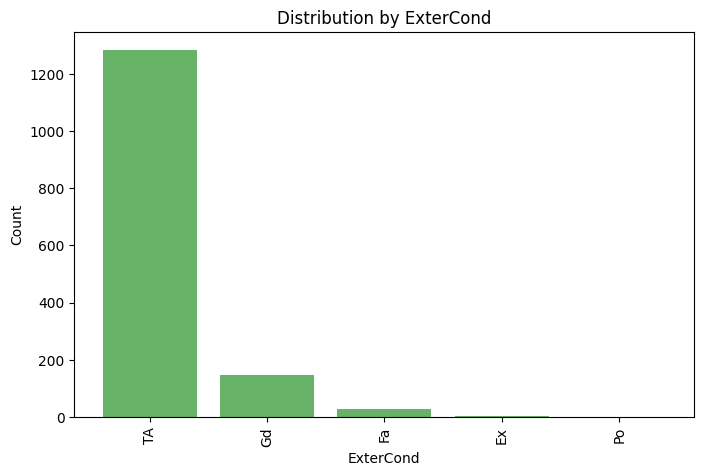

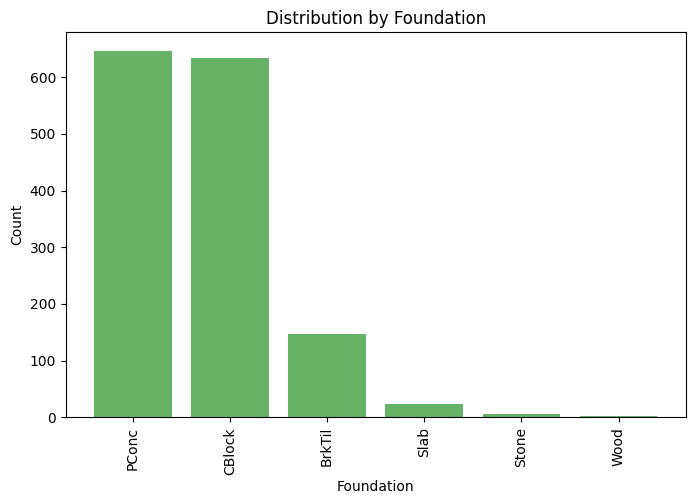

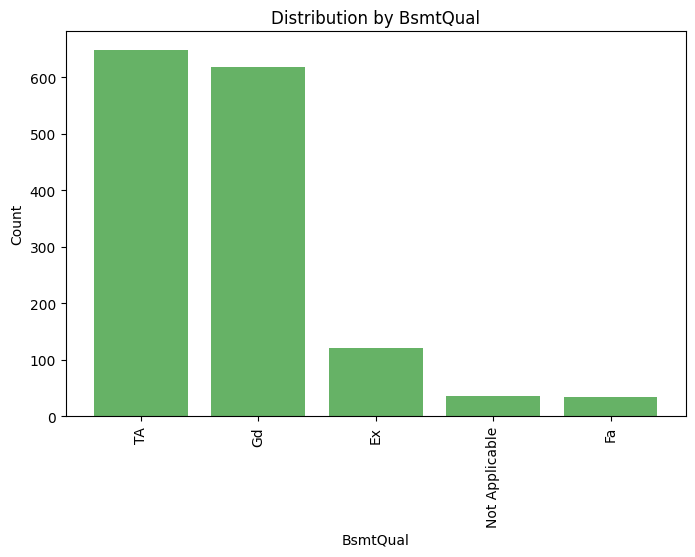

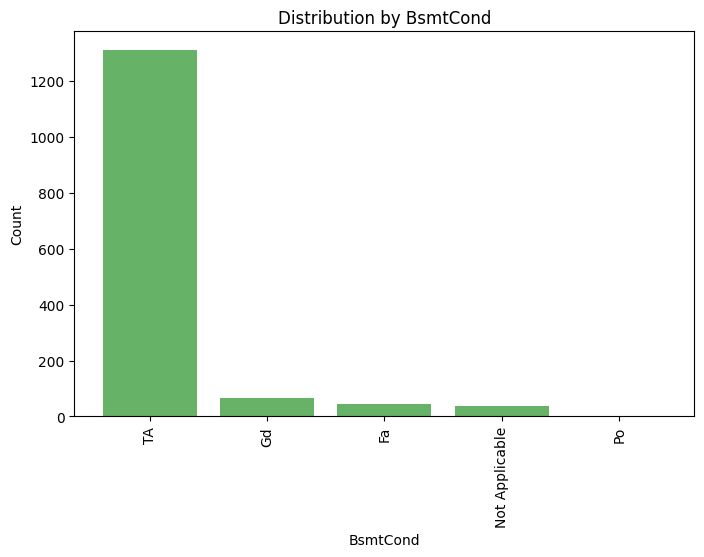

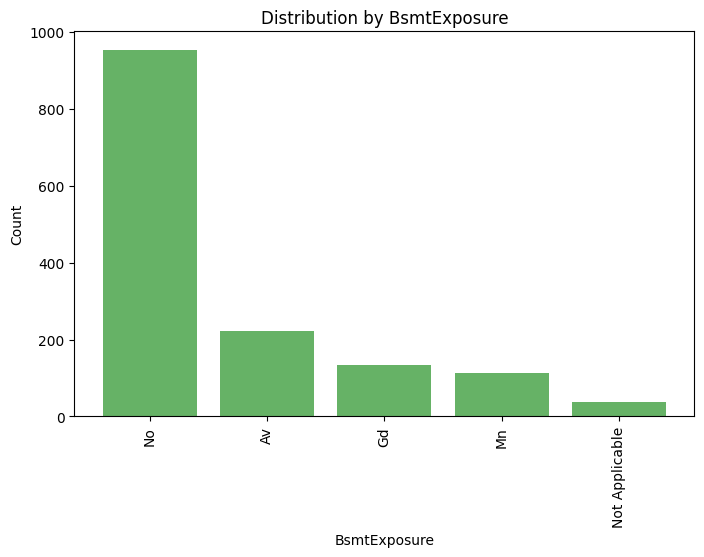

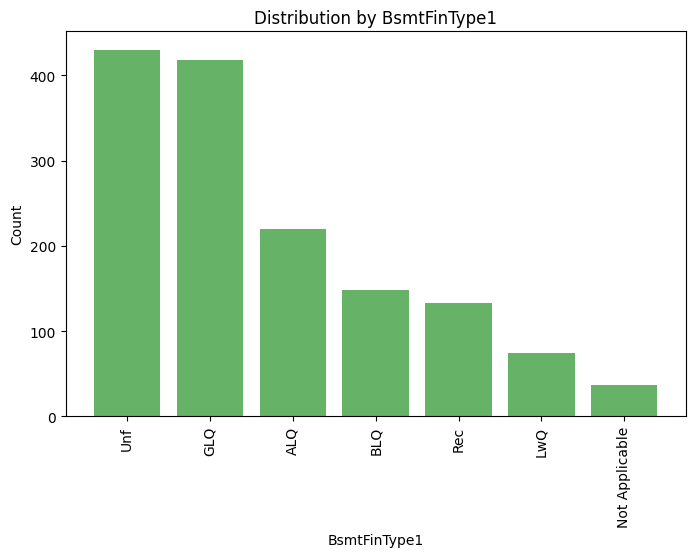

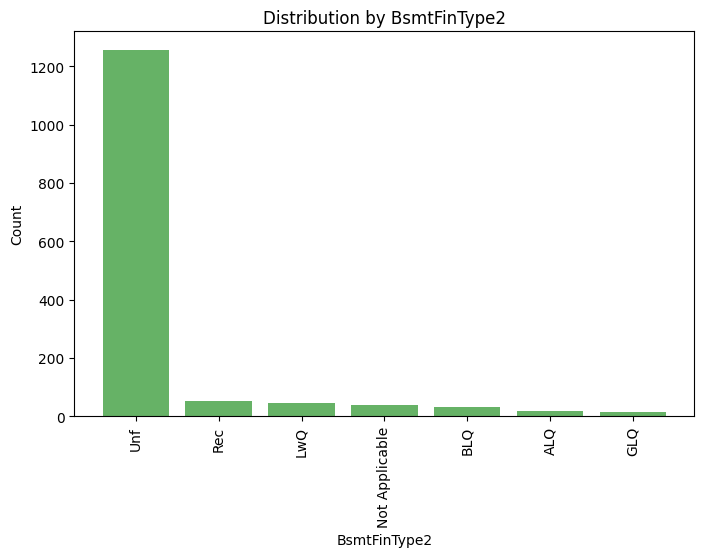

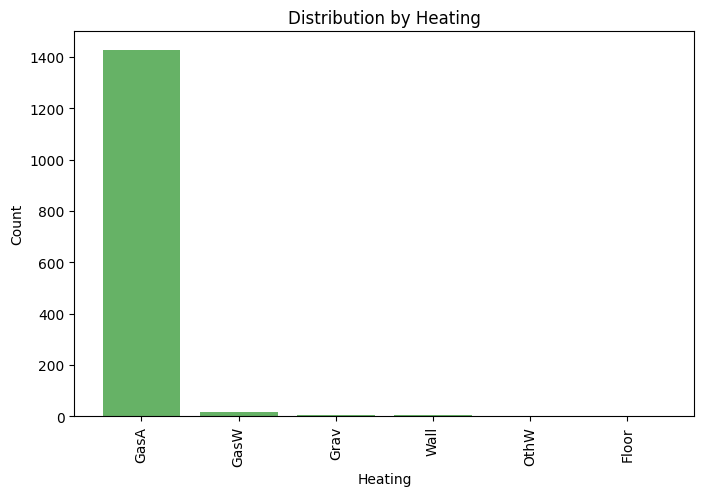

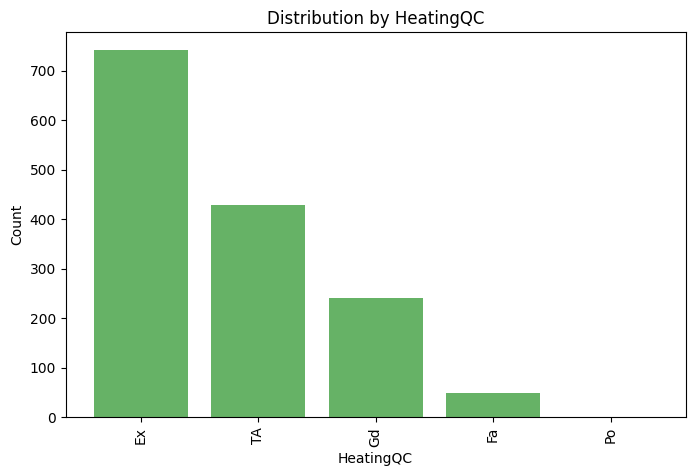

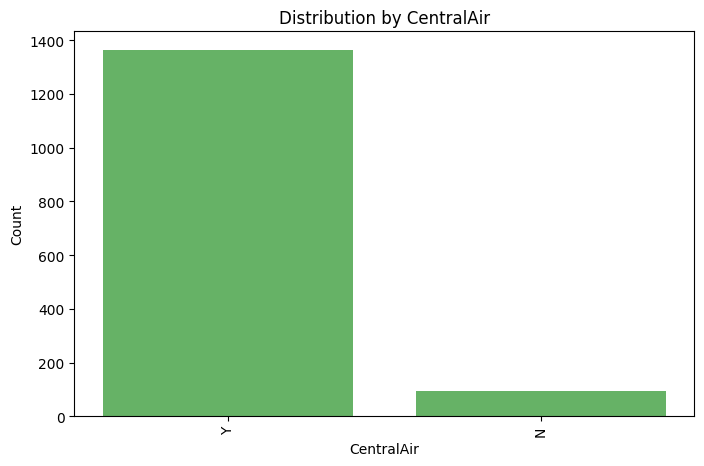

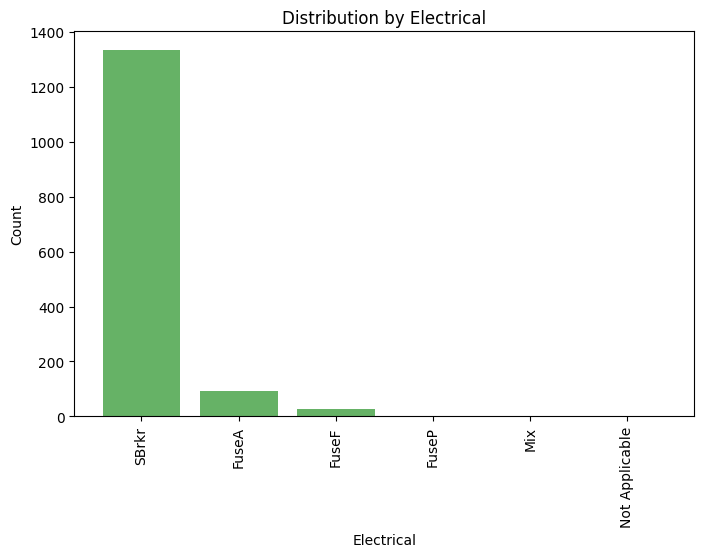

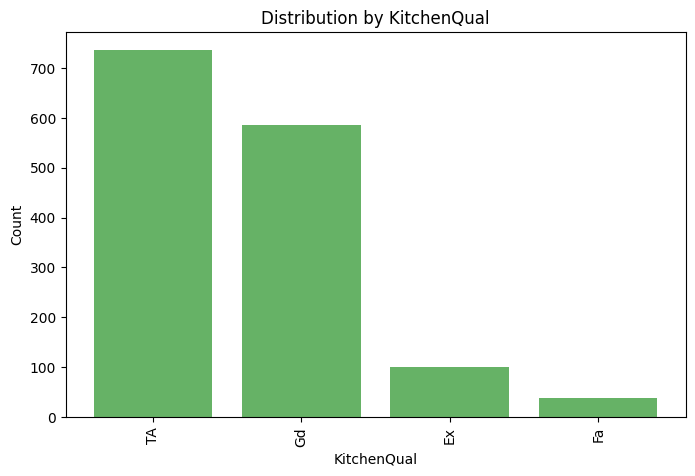

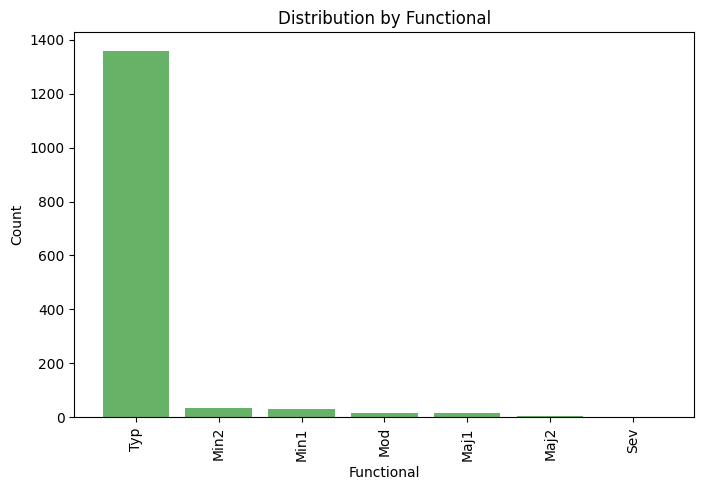

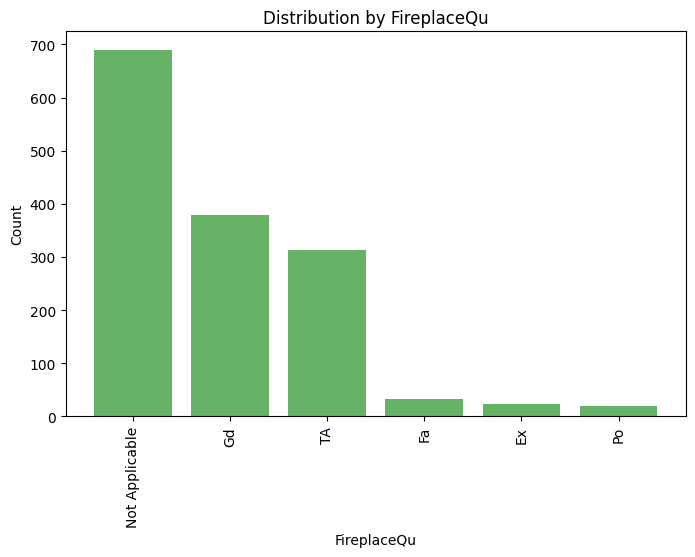

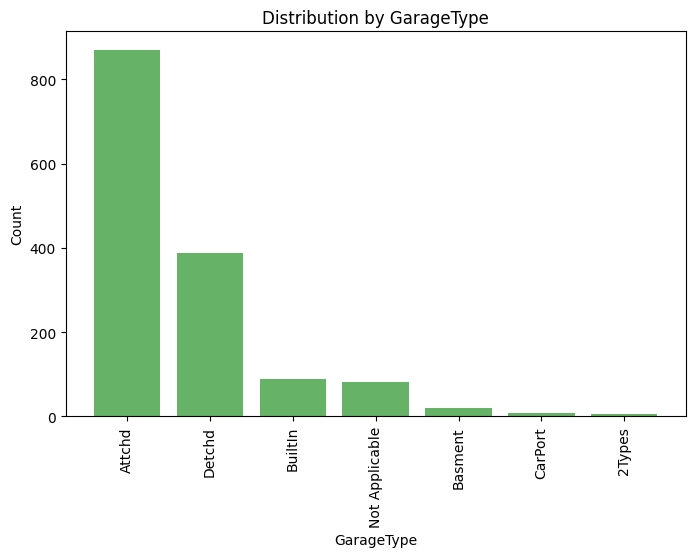

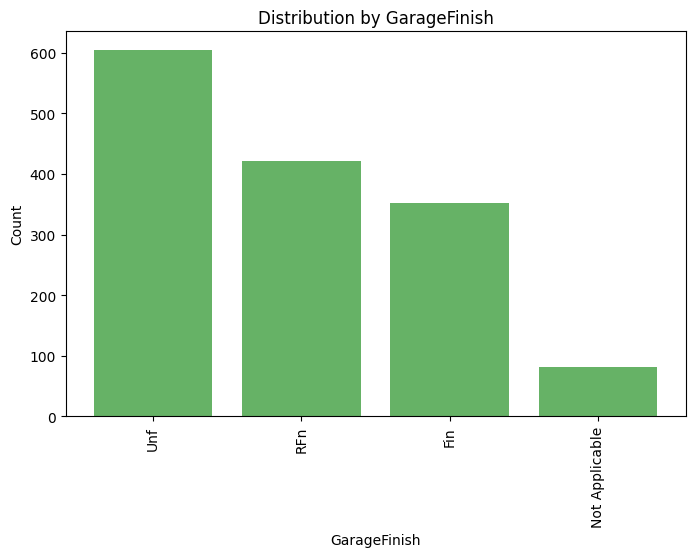

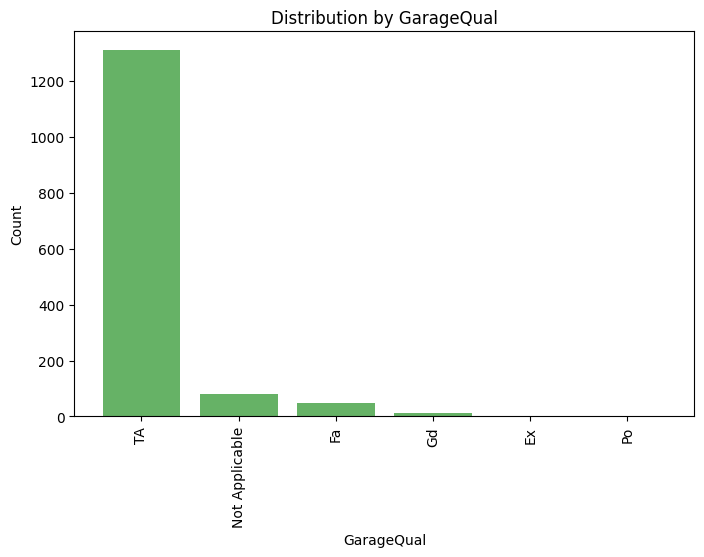

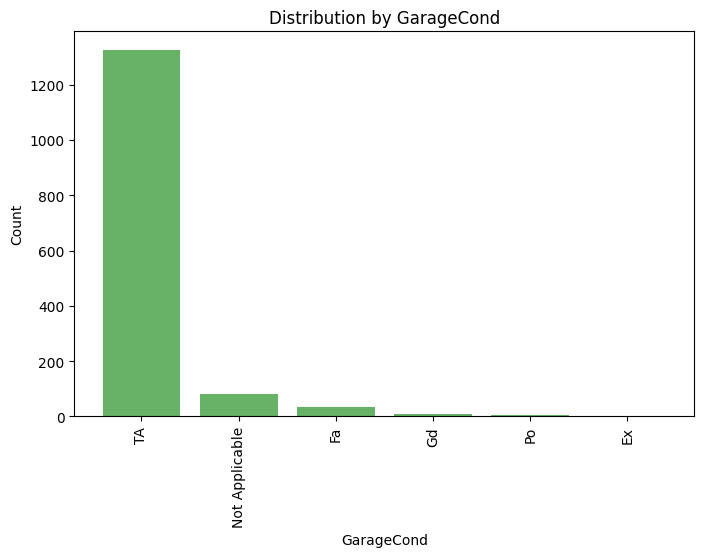

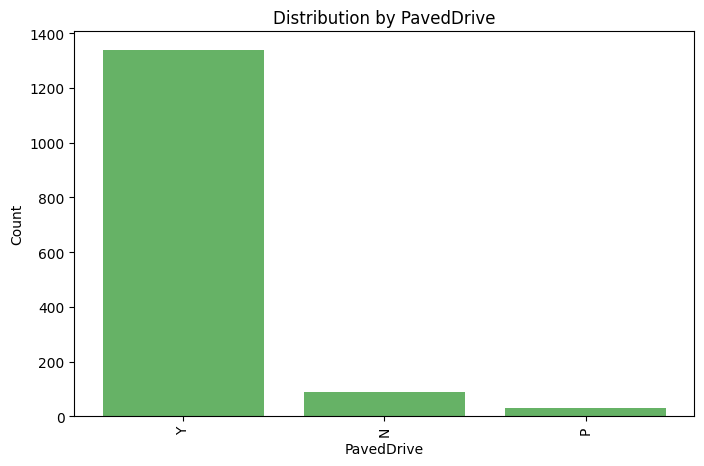

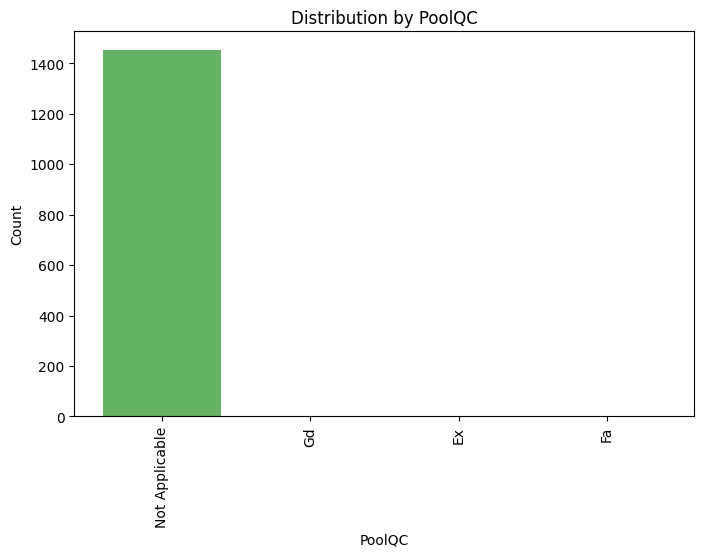

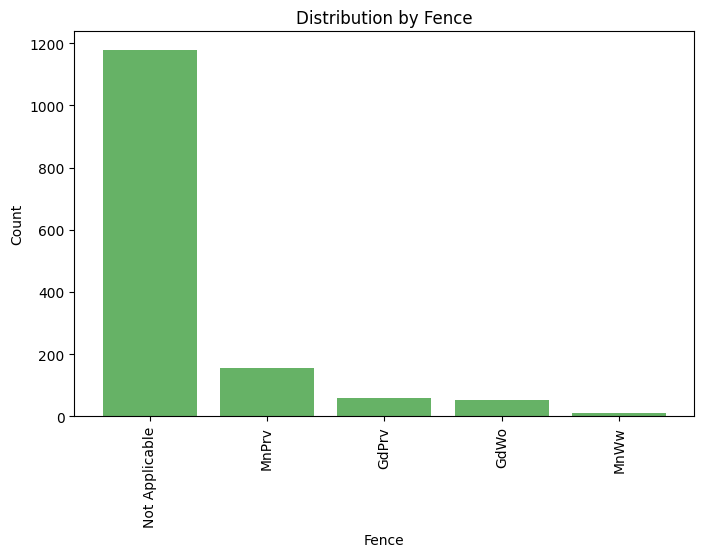

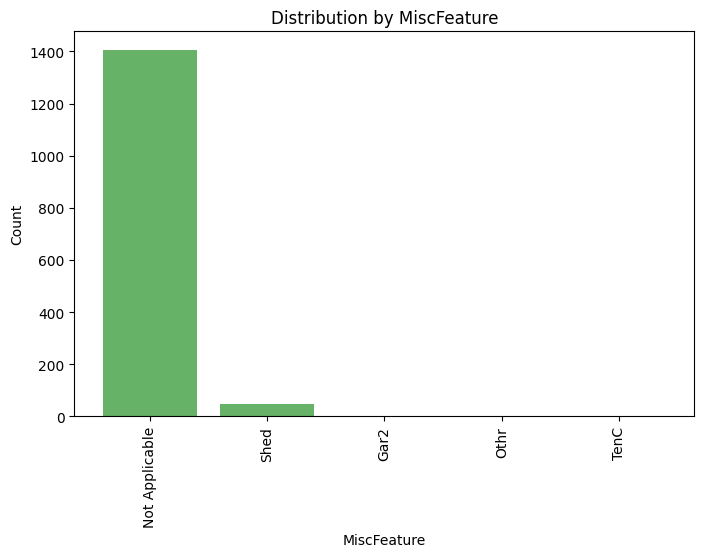

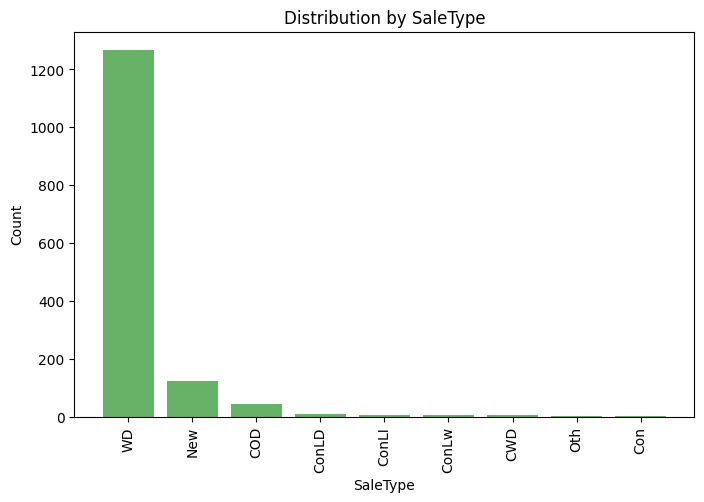

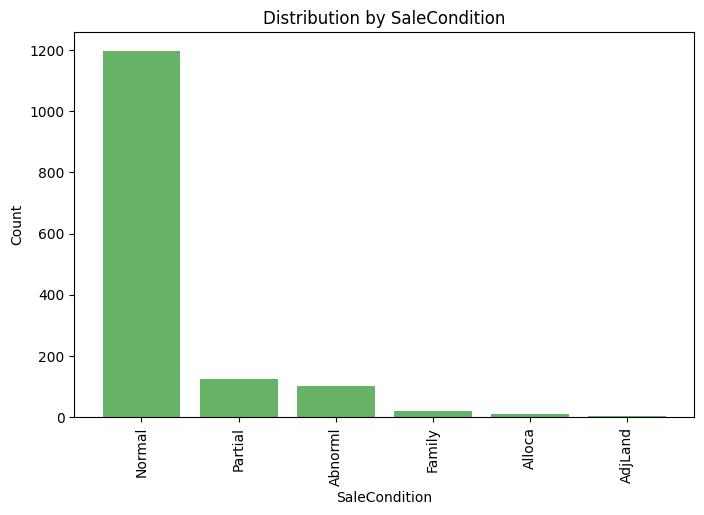

In [58]:
# Creating plots for each categorical variable
for col in categorical_data.columns:
    if col != 'SalePrice':  # Skip if the column is 'SalePrice'
        category_counts = categorical_data[col].value_counts()

        fig, ax1 = plt.subplots(figsize=(8, 5))

        # Bar plot for category counts
        ax1.bar(category_counts.index, category_counts.values, alpha=0.6, color='green', label='Count')
        ax1.set_ylabel('Count', color='black')
        ax1.set_xlabel(col)

        # Rotate x-axis labels to 90 degrees
        plt.xticks(rotation=90)
        plt.title(f'Distribution by {col}')
        plt.show()


### Median Value per category

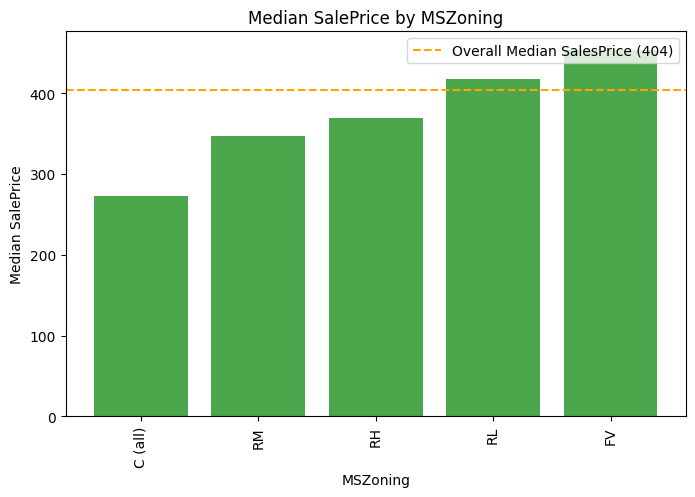

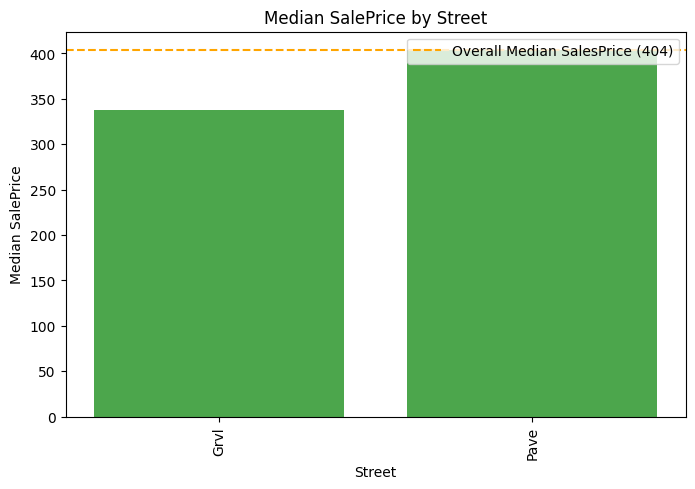

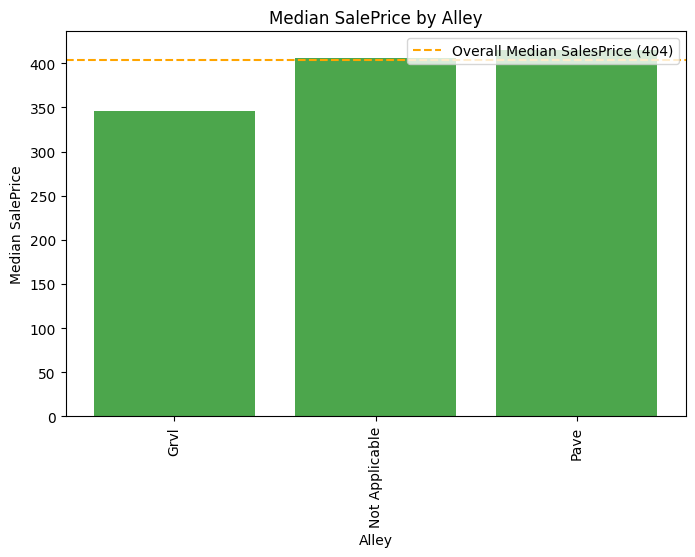

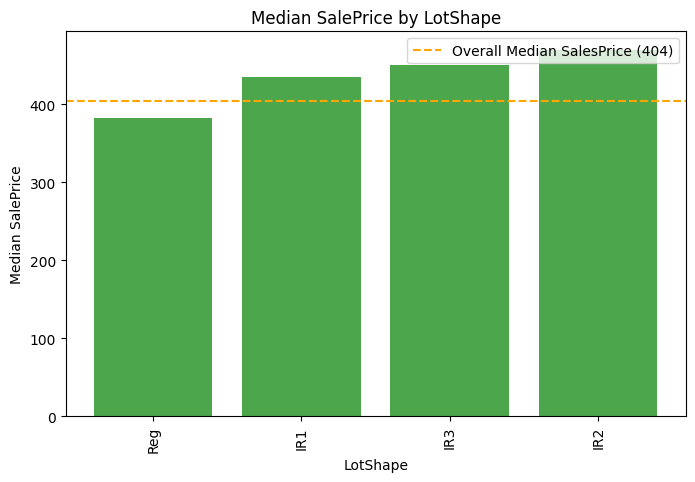

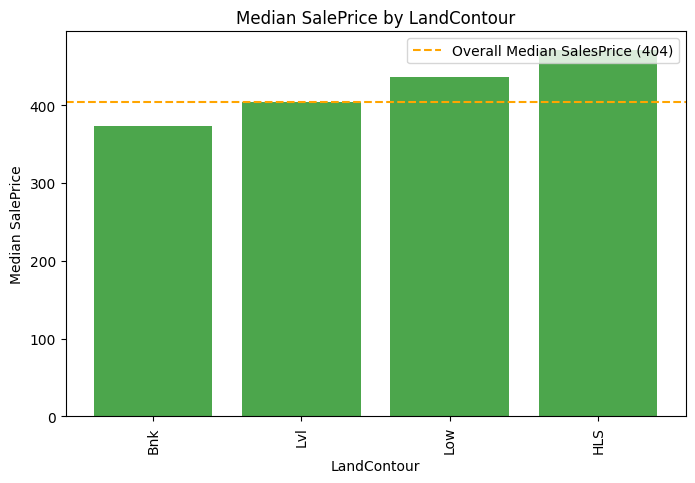

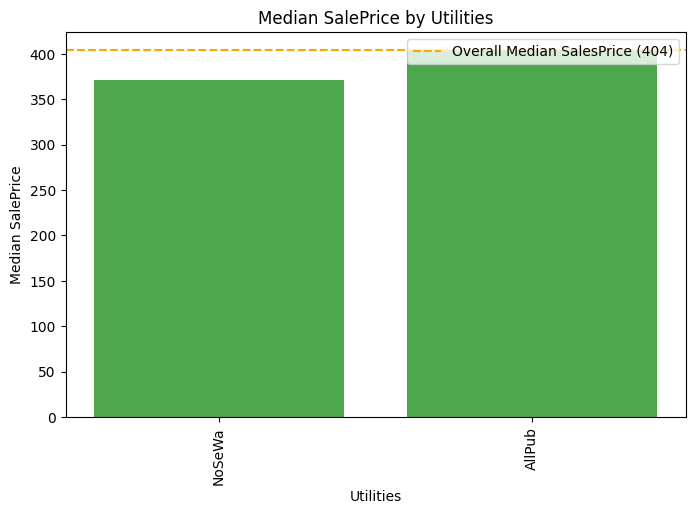

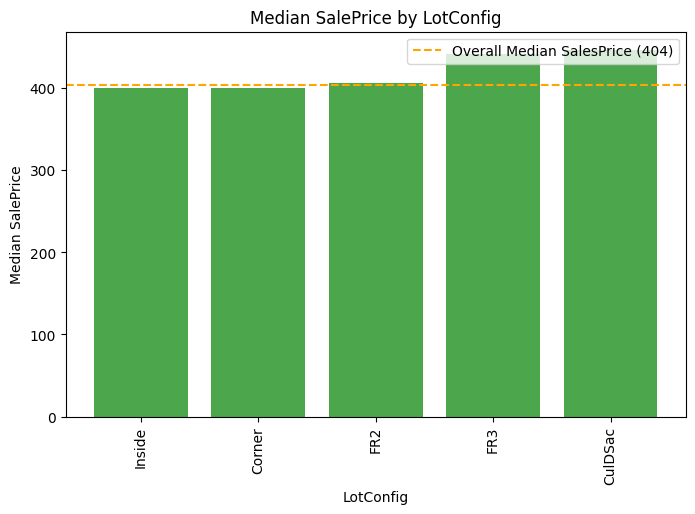

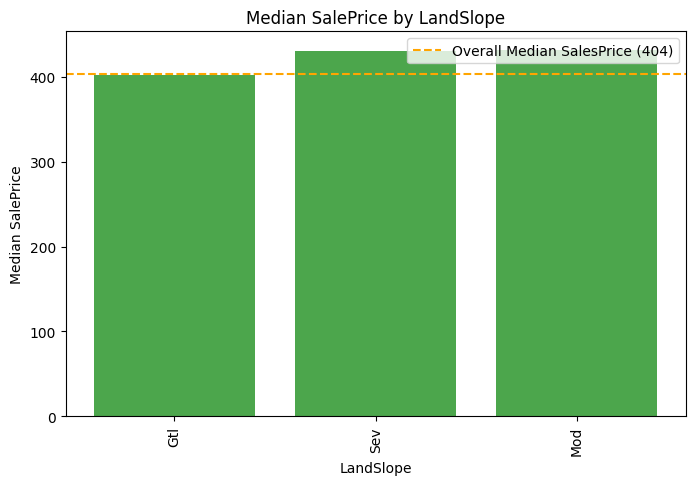

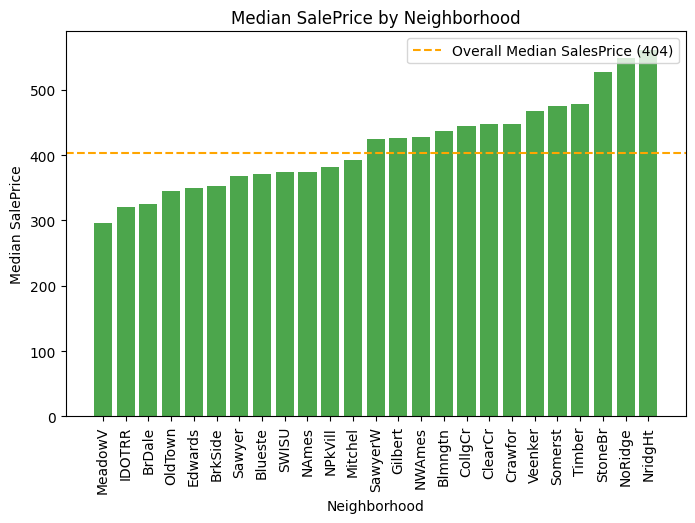

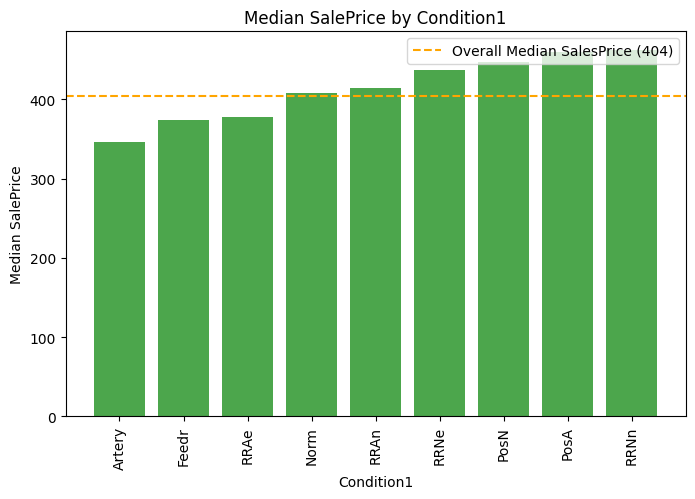

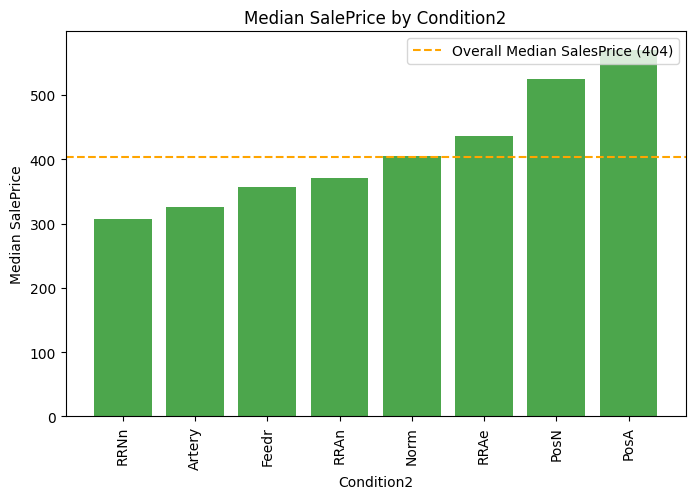

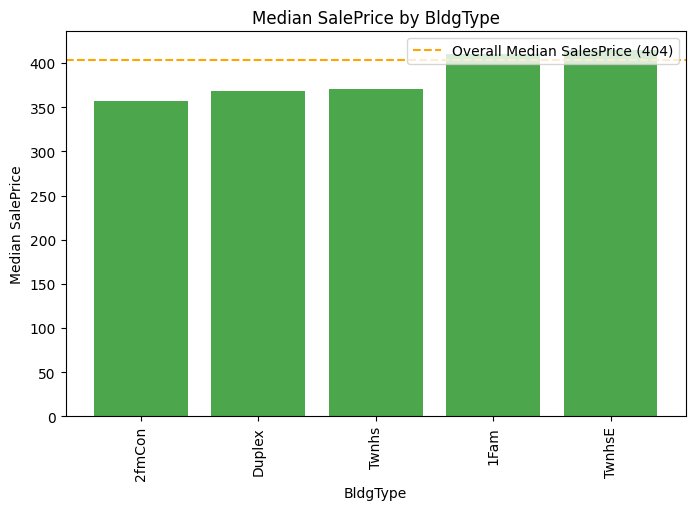

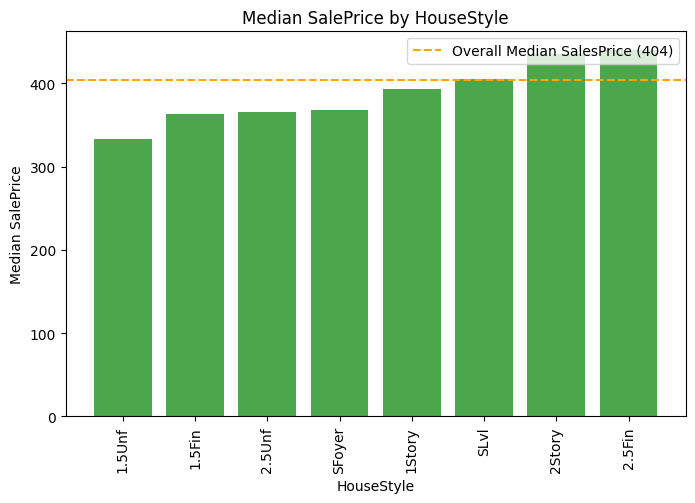

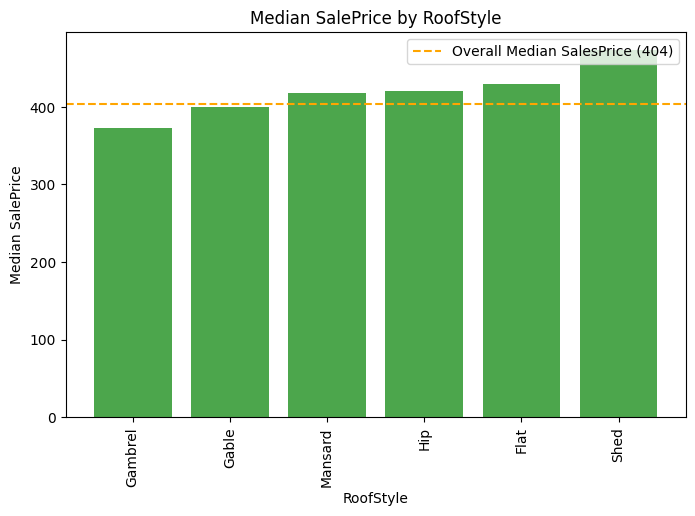

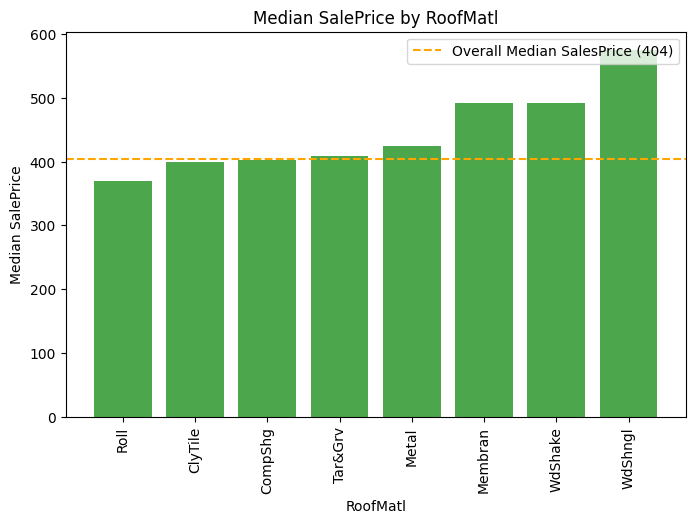

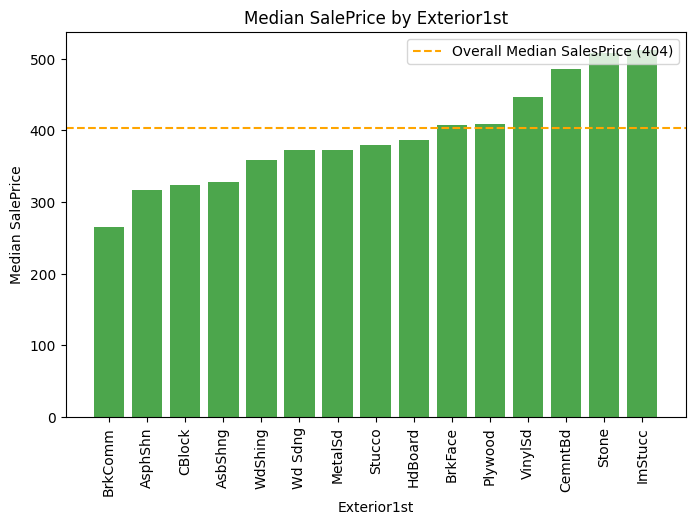

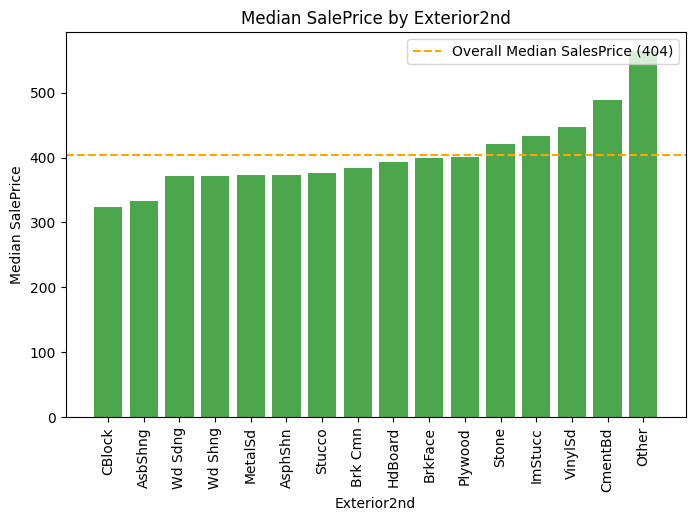

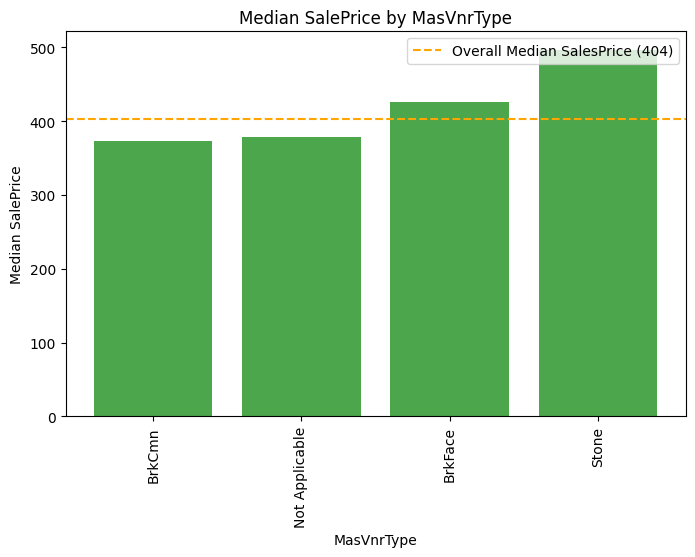

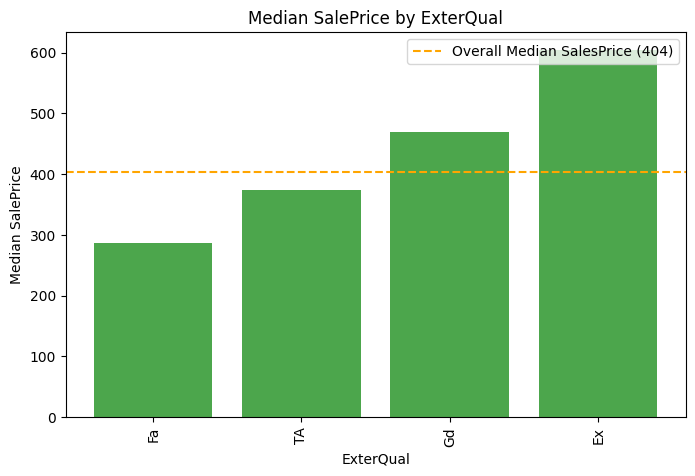

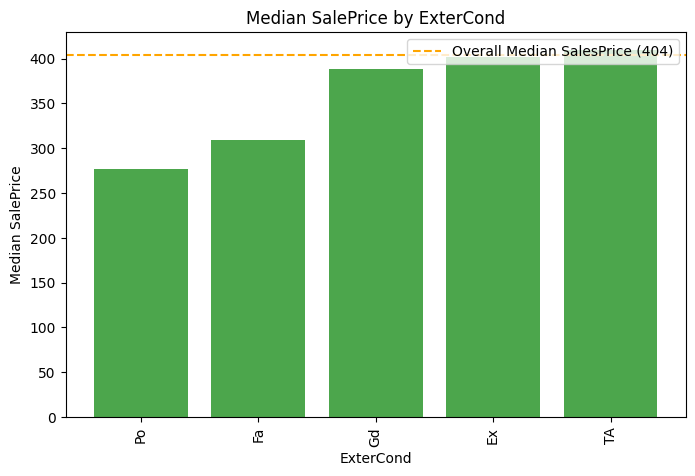

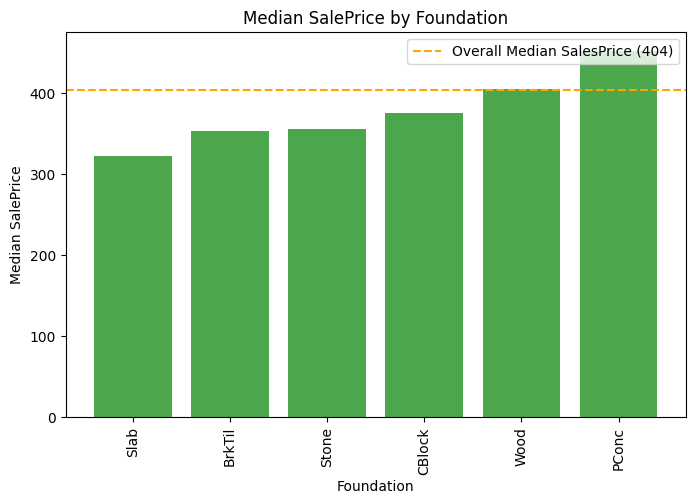

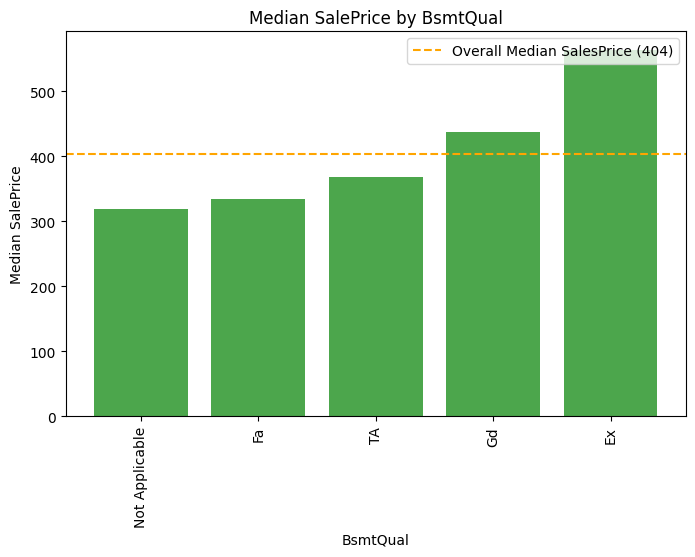

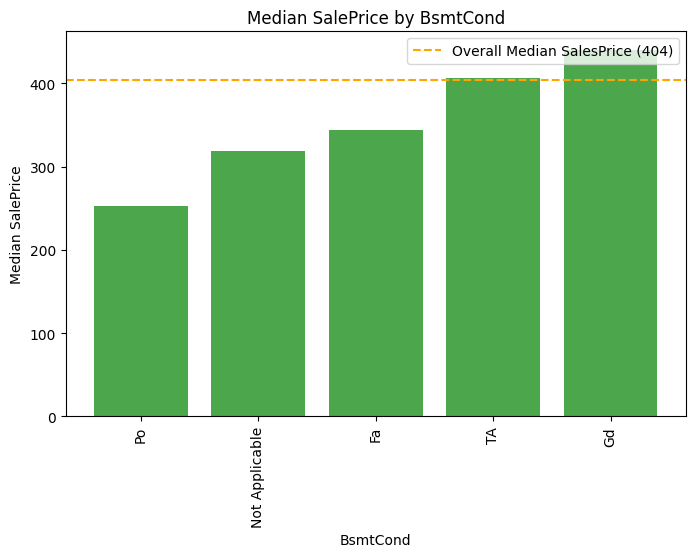

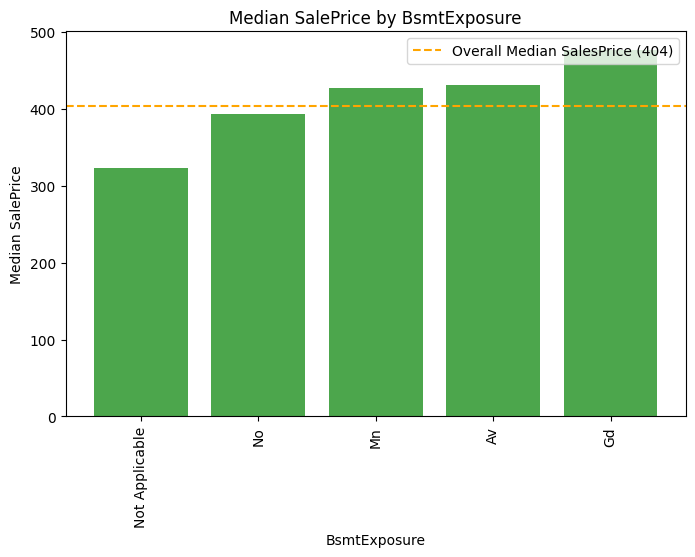

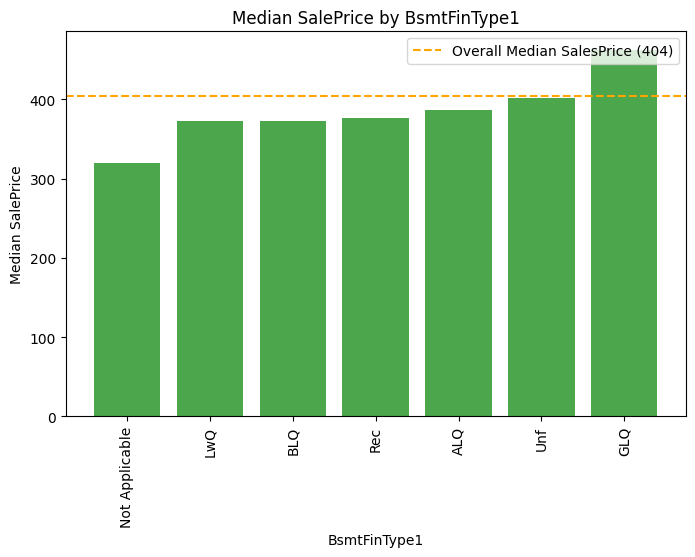

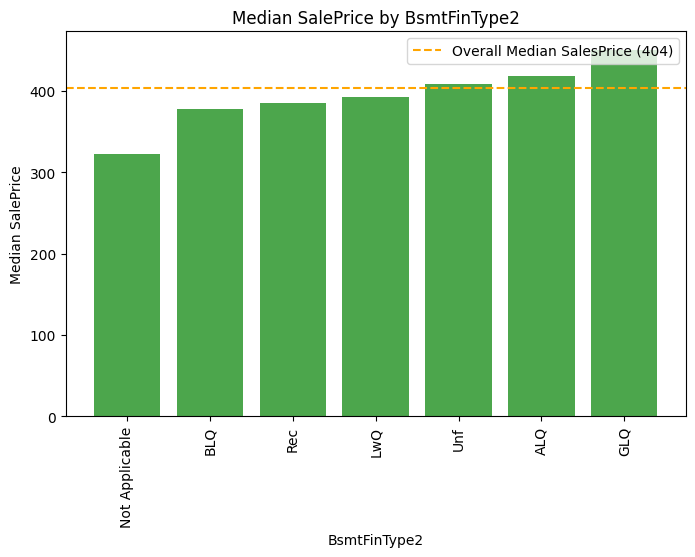

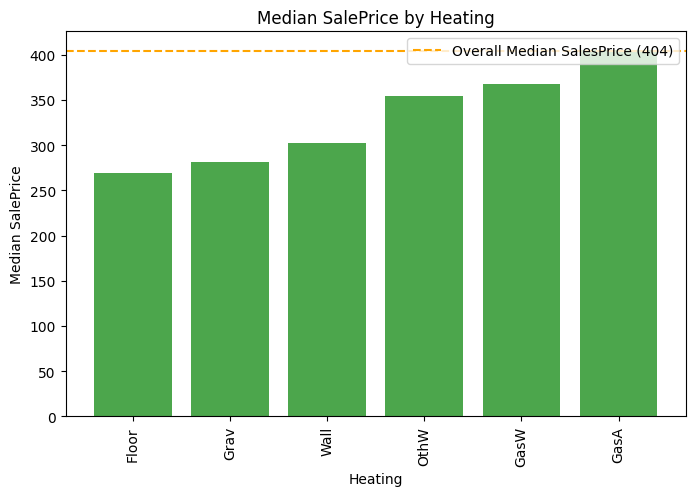

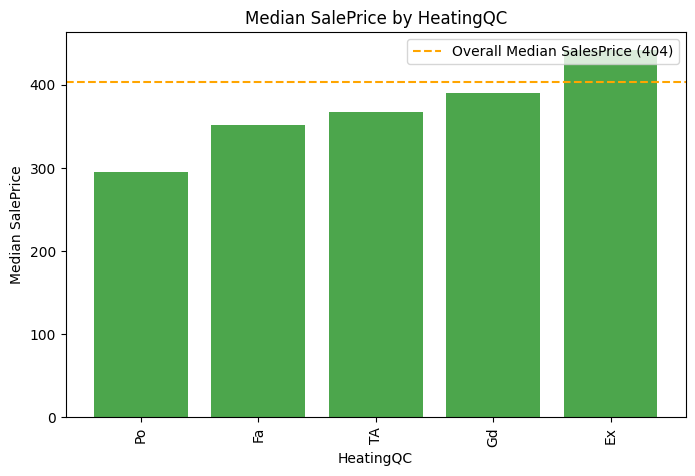

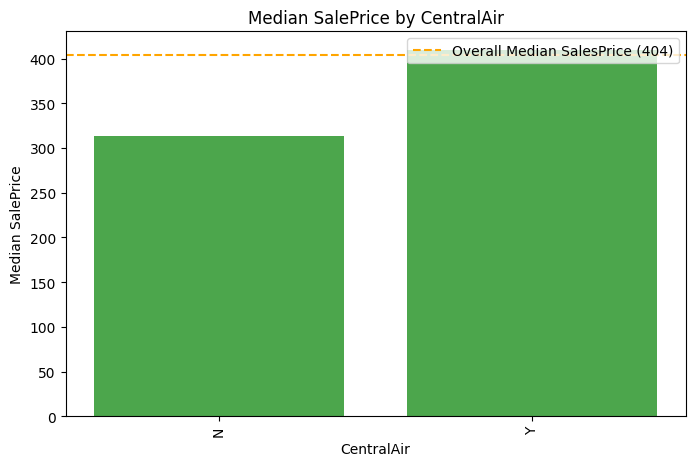

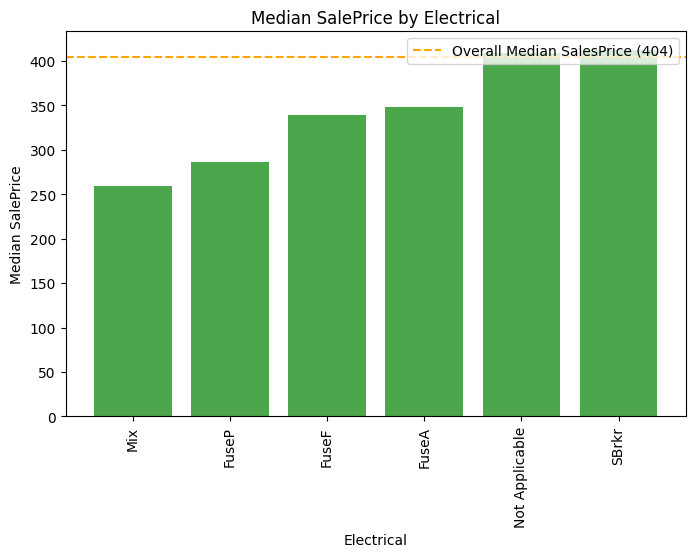

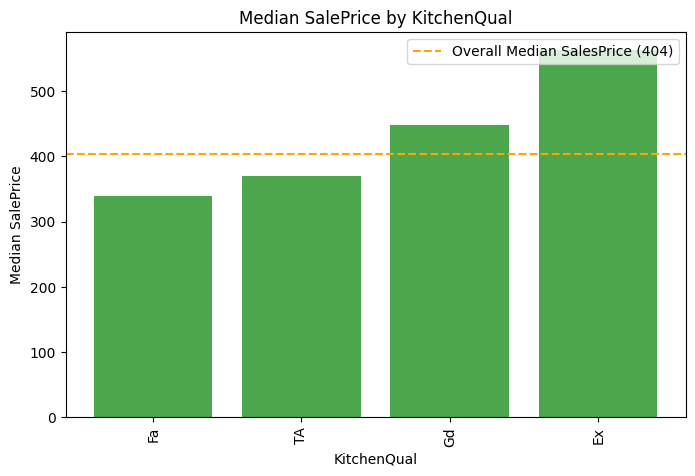

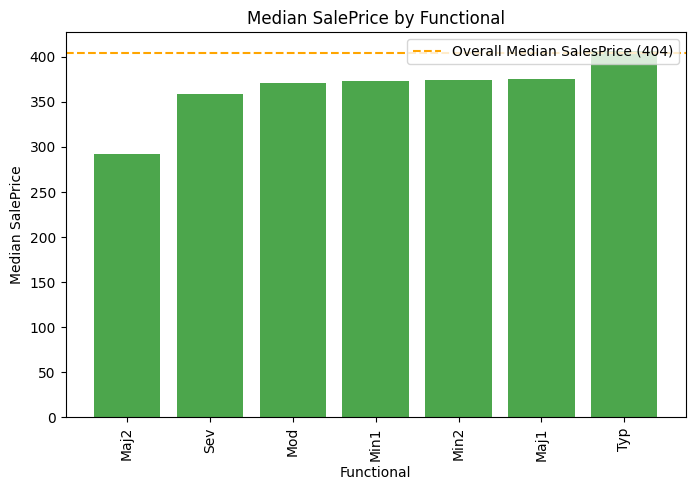

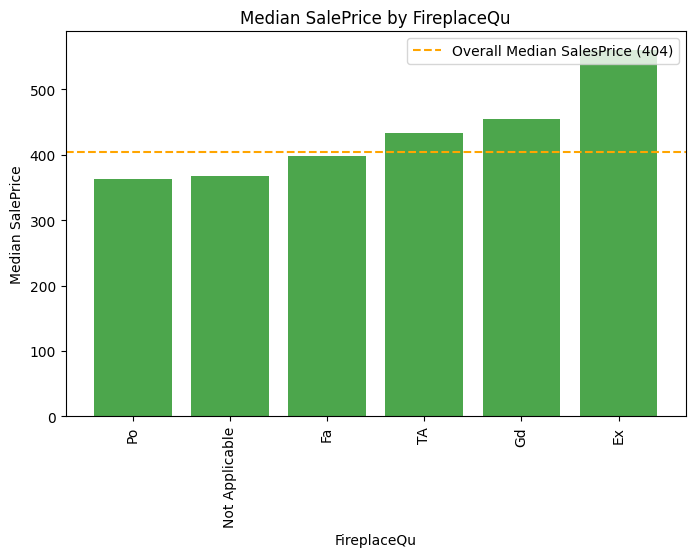

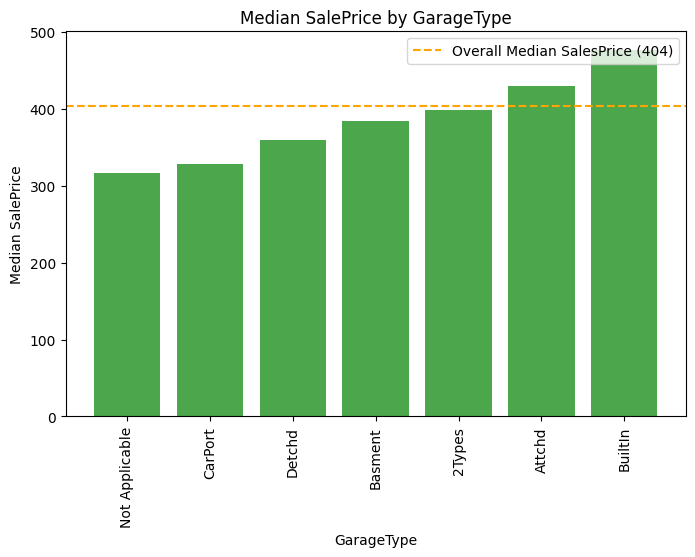

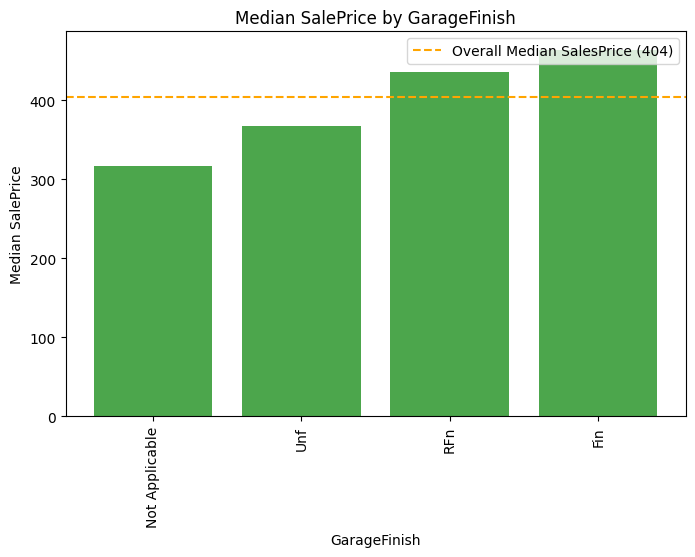

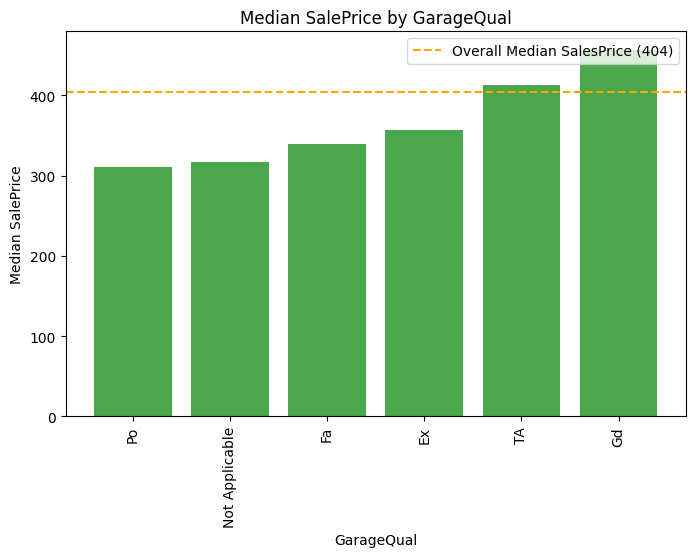

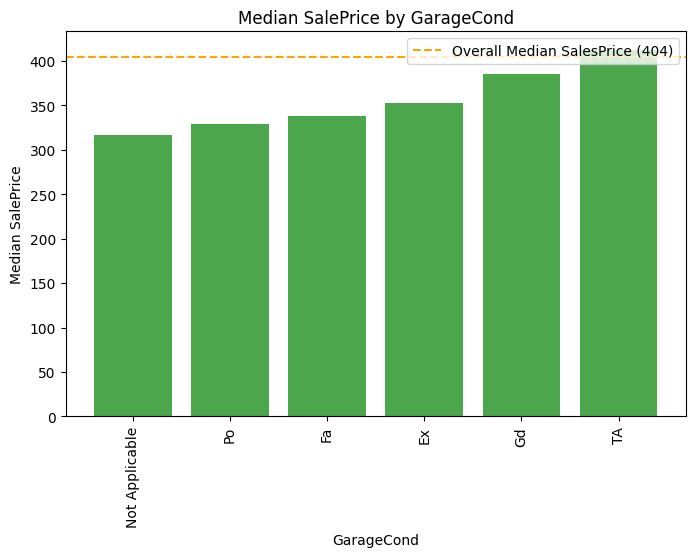

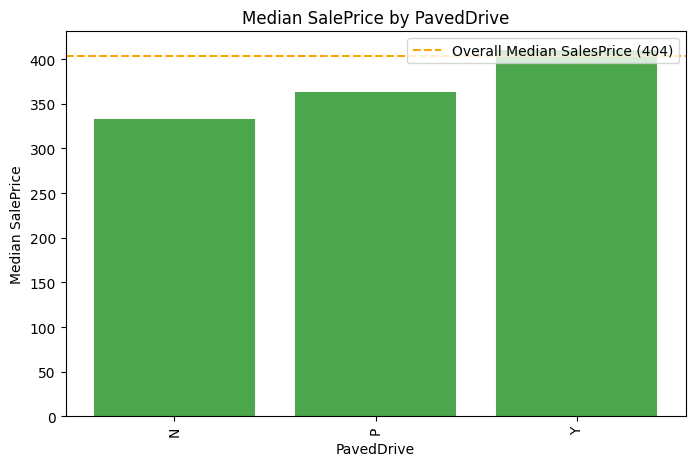

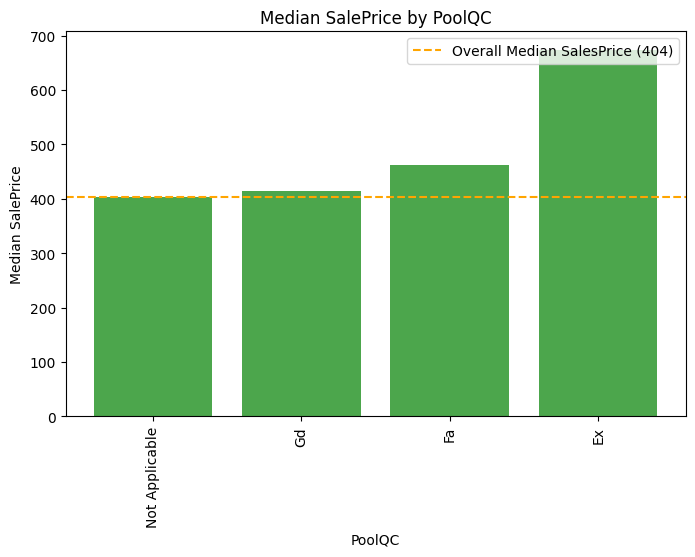

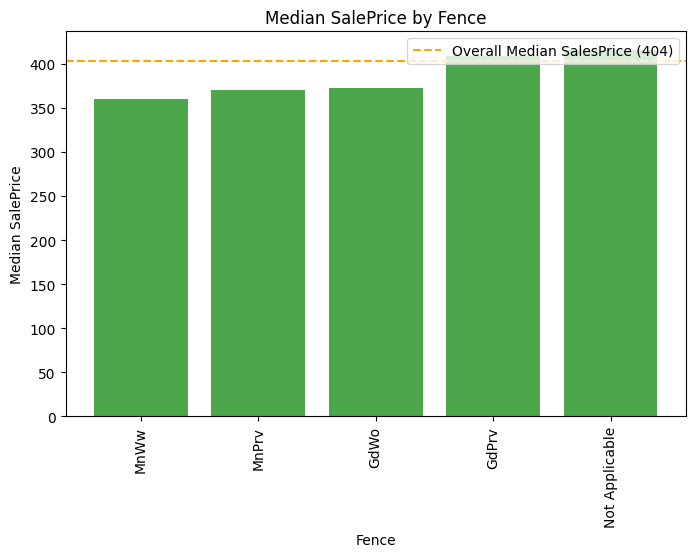

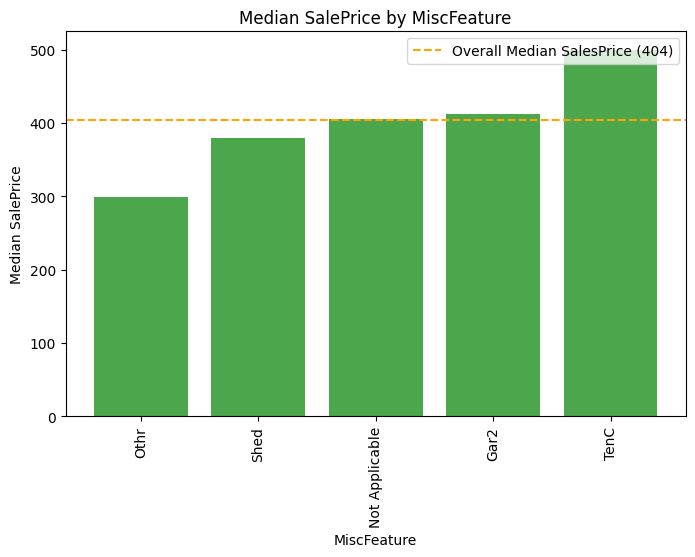

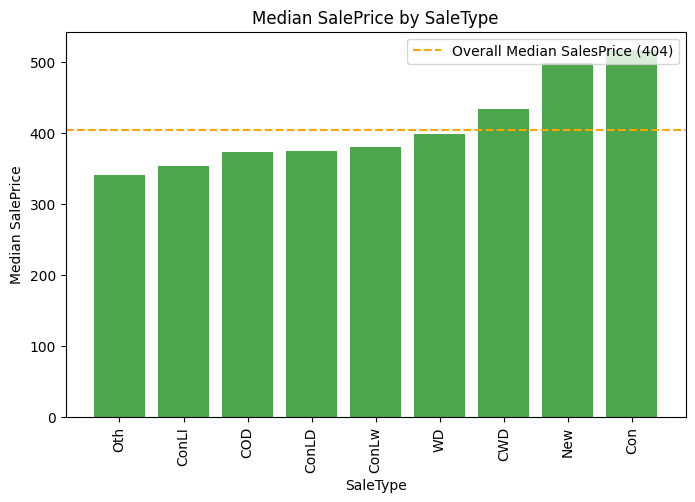

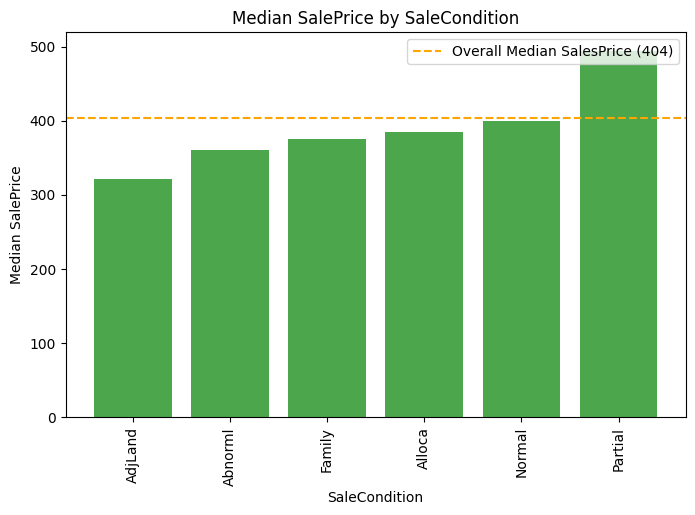

In [59]:
# Select categorical columns (excluding SalePrice)
categorical_data = df.select_dtypes(include=['object'])

# Compute overall median of SalePrice
overall_median = df['SalePrice'].median()

# Creating plots for each categorical variable (EXCLUDING SalePrice)
for col in categorical_data.columns:
    # Calculate median SalePrice for each category
    category_medians = df.groupby(col)['SalePrice'].median().sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))

    # Bar plot for median SalePrice per category (EXCLUDE from legend)
    bars = ax.bar(category_medians.index, category_medians.values, color='green', alpha=0.7)

    ax.set_ylabel('Median SalePrice', color='black')
    ax.set_xlabel(col)
    
    # Rotate x-axis labels to 90 degrees for readability
    plt.xticks(rotation=90)

    # Add an overall median line (WITH legend)
    median_line = ax.axhline(y=overall_median, color='orange', linestyle='--', label=f'Overall Median SalesPrice ({overall_median:,.0f})')

    # Manually set legend, excluding bar plot
    ax.legend(handles=[median_line], loc='upper right')

    # Add title
    plt.title(f'Median SalePrice by {col}')

    plt.show()


#### Notes on the distribution
Based on the preliminary view the following variables are highly skewed and should be removed or grouped:

**Grouped**

Neighborhood (5 x median SalePrice), Roofstyle(Gable, Hip), RoofMatl (CompShg), ExterCond (TA, Gd + EX) BsmtCond (TA & Gd), BsmtFinType2 (Unf + ALQ + GLQ), Heating (GasA), Electrical (SBrkr) Functional (Typ), GarageQual (TA + Gd), GarageCond (TA + Gd)

**Removed**

Street, Alley, Utilities, Condition2, PoolQC, MiscFeature

In [61]:
# Export the reviewed data with the excluded columns to create a new csv
# Create a list of columns to exclude
columns_to_exclude = ['Street', 'Alley', 'Utilities', 'Condition2', 'PoolQC', 'MiscFeature']

# Drop the columns from the data
df = df.drop(columns_to_exclude, axis=1)

# Export the data to a new csv file
df.to_csv('outputs/train_cleaned_trimmed.csv', index=False)